# Práctica de Laboratorio 1: Clasificación de Imágenes Médicas (Retinopatía Diabética)
**Asignatura:** Aprendizaje Automático III (IN1042)  
**Profesor:** Dr. Arturo Navarro  
**Caso de Estudio Transversal:** Proyecto "Behe" (Prevención de ceguera mediante IA)


# BLOQUE 1: INTRODUCCIÓN Y VERIFICACIÓN

## 1. Contexto Clínico y Compromiso Ético
De acuerdo con el enfoque humanista de la Universidad Iberoamericana, la Inteligencia Artificial debe orientarse a la transformación social y al bien común. En esta práctica abordaremos la **retinopatía diabética**, una de las principales causas de ceguera prevenible a nivel mundial.

Nuestro objetivo es construir un sistema de visión por computadora capaz de clasificar retinografías (fotografías del fondo de ojo). Desde el punto de vista ético y legal, el manejo de datos médicos exige un diseño algorítmico robusto que minimice los falsos negativos (pacientes enfermos clasificados como sanos) e incorpore explicabilidad, evitando el sesgo algorítmico y respetando la privacidad del paciente.

## 2. Bloque de Auditoría: Aceleración por Hardware (GPU) y Multi-Backend
El entrenamiento de arquitecturas convolucionales avanzadas con imágenes médicas de alta resolución es computacionalmente exhaustivo. En esta sesión utilizaremos **Keras 3**. Dado que operamos en un entorno local Windows, configuraremos Keras para utilizar **PyTorch** como motor (*backend*), lo que nos permitirá acceder de manera nativa a la aceleración por hardware (CUDA) sin las complejidades de configuración que TensorFlow requiere en Windows nativo.

In [18]:
import os
import torch

# 1. Forzamos a Keras 3 a utilizar PyTorch como backend de ejecución computacional
os.environ["KERAS_BACKEND"] = "torch"
import keras
import numpy as np

print("--- Auditoría de Hardware y Entorno Clínico ---")
print(f"Versión de Keras: {keras.__version__}")
print(f"Motor (Backend) activo en Keras: {keras.backend.backend()}")

# 2. Verificación de aceleración por GPU mediante PyTorch
gpu_disponible = torch.cuda.is_available()
print(f"\n¿PyTorch detecta la GPU NVIDIA (CUDA)?: {gpu_disponible}")

if gpu_disponible:
    print(f"Tarjeta Gráfica detectada: {torch.cuda.get_device_name(0)}")
    print("Estado: Óptimo para entrenamiento.")
else:
    print("ADVERTENCIA: No se detectó GPU. El entrenamiento de imágenes médicas será críticamente lento.")

--- Auditoría de Hardware y Entorno Clínico ---
Versión de Keras: 3.15.1
Motor (Backend) activo en Keras: torch

¿PyTorch detecta la GPU NVIDIA (CUDA)?: True
Tarjeta Gráfica detectada: NVIDIA GeForce RTX 4050 Laptop GPU
Estado: Óptimo para entrenamiento.


## 3. Arquitectura del Modelo: API Secuencial vs. API Funcional
En Aprendizaje Automático II comprendimos las bases del Deep Learning. Para problemas médicos complejos (donde utilizaremos arquitecturas como ResNet, Inception o U-Net para segmentación semántica), la **API Secuencial** resulta insuficiente, ya que no permite bifurcaciones ni conexiones residuales (*skip connections*), fundamentales para evitar el desvanecimiento del gradiente en redes profundas.

A continuación, contrastaremos rápidamente cómo se define un clasificador base de retinografías usando la API Secuencial frente al estándar de la industria: la **API Funcional**.

In [19]:
from keras import layers

# Parámetros estándar para imágenes médicas (Ej. Retinografías recortadas a 224x224 en RGB)
IMG_SHAPE = (224, 224, 3)

# =====================================================================
# ENFOQUE 1: API SECUENCIAL (Limitado - Flujo Lineal)
# =====================================================================
modelo_secuencial = keras.Sequential([
    layers.Input(shape=IMG_SHAPE, name="Input_Retinografia"),
    layers.Rescaling(1./255, name="Normalizacion"),
    layers.Conv2D(32, 3, activation="relu", padding="same", name="Conv_1"),
    layers.MaxPooling2D(2, name="Pool_1"),
    layers.Flatten(name="Aplanado"),
    layers.Dense(1, activation="sigmoid", name="Salida_Clinica")
], name="CNN_Secuencial_Basica")

print("--- Resumen API Secuencial ---")
modelo_secuencial.summary()


# =====================================================================
# ENFOQUE 2: API FUNCIONAL (Estándar Profesional y Clínico)
# =====================================================================
# La API funcional trata cada capa como una función matemática pura f(x)
inputs = keras.Input(shape=IMG_SHAPE, name="Input_Retinografia_Funcional")

# Preprocesamiento integrado en el grafo
x = layers.Rescaling(1./255, name="Normalizacion_Clinica")(inputs)

# Extracción de características
x = layers.Conv2D(32, 3, activation="relu", padding="same", name="Conv_Base")(x)
x = layers.MaxPooling2D(2, name="Pool_Base")(x)

# Para evitar parámetros excesivos (overfitting), en lugar de Flatten usamos GlobalAveragePooling
x = layers.GlobalAveragePooling2D(name="Compactacion_Espacial")(x)

# Salida Binaria: 0 (Sano) vs 1 (Retinopatía Diabética)
outputs = layers.Dense(1, activation="sigmoid", name="Diagnostico_Binario")(x)

modelo_funcional = keras.Model(inputs=inputs, outputs=outputs, name="CNN_Funcional_Medica")

print("\n--- Resumen API Funcional ---")
modelo_funcional.summary()

--- Resumen API Secuencial ---


Model: "CNN_Secuencial_Basica"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Normalizacion (Rescaling)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_1 (MaxPooling2D)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado (Flatten)              │ (None, 401408)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida_Clinica (Dense)          │ (None, 1)              │       401,409 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,305 (1.53 MB)

 Trainable params: 402,305 (1.53 MB)

...

Model: "CNN_Funcional_Medica"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Retinografia_Funcional    │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Normalizacion_Clinica           │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Base (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_Base (MaxPooling2D)        │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Compactacion_Espacial           │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Diagnostico_Binario (Dense)     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Control de Entrenamiento: Callbacks en Entornos de Producción Médica
En la validación de modelos clínicos, el sobreajuste (*overfitting*) es nuestro mayor enemigo, dado que los datasets médicos suelen ser limitados y desbalanceados. Entrenar a ciegas puede resultar en un modelo que memorice los datos de entrenamiento pero falle estrepitosamente con un paciente nuevo.

Implementaremos *Callbacks* preventivos:
1. **EarlyStopping:** Monitorea la función de pérdida de validación (`val_loss`). Si la red comienza a sobreajustarse y deja de generalizar, detiene la ejecución.
2. **ModelCheckpoint:** Guarda automáticamente los pesos (weights) exactos del modelo en la época donde obtuvo el mejor rendimiento diagnóstico, descartando las épocas degradadas por overfitting.

In [20]:
def obtener_callbacks_clinicos(nombre_experimento):
    """
    Genera una lista de callbacks de Keras optimizada para modelos de diagnóstico.
    """
    callbacks = [
        # Detiene el entrenamiento si la métrica no mejora en 4 épocas
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        # Guarda en disco el archivo .keras de la mejor iteración
        keras.callbacks.ModelCheckpoint(
            filepath=f"mejor_modelo_retinopatia_{nombre_experimento}.keras",
            save_best_only=True,
            monitor="val_loss",
            verbose=1
        )
    ]
    return callbacks

print("Pipelines de Callbacks clínicos definidos y listos para inyección en el método .fit()")

Pipelines de Callbacks clínicos definidos y listos para inyección en el método .fit()


# BLOQUE 2: Preparación e Ingesta del Dataset Médico (APTOS 2019)

## 1. Descarga e Ingesta de Retinografías
Para el entrenamiento de nuestros modelos en el proyecto **Behe**, utilizaremos el dataset **APTOS 2019 Blindness Detection**. Este conjunto de datos contiene miles de fotografías de fondo de ojo (retinografías) capturadas en condiciones clínicas reales en la India.

A diferencia del dataset tradicional de "Cats vs Dogs", donde los archivos están organizados físicamente en subcarpetas (`cats/` y `dogs/`), las imágenes médicas suelen almacenarse en un único directorio acompañadas de un archivo de metadatos o manifiesto clínico (`train.csv`). Este archivo vincula el identificador único de la imagen (`id_code`) con la severidad del diagnóstico determinado por epidemiólogos y oftalmólogos (`diagnosis`).

Escala de Severidad de Retinopatía Diabética (DR):
- **Grado 0:** Sin Retinopatía Diabética (Sano)
- **Grado 1:** Leve (Mild)
- **Grado 2:** Moderada (Moderate)
- **Grado 3:** Severa (Severe)
- **Grado 4:** Proliferativa (Proliferative DR)

In [21]:
import os
import kagglehub
import pandas as pd
import shutil

In [22]:
# Configuración segura de credenciales de Kaggle
import json
from pathlib import Path
from getpass import getpass

# Usa KAGGLE_USERNAME del sistema si existe; si no, usa el tuyo por defecto
kaggle_user = os.getenv("KAGGLE_USERNAME", "rsdzkaggle")
os.environ["KAGGLE_USERNAME"] = kaggle_user

# Si KAGGLE_KEY no está en el entorno, se solicita de forma oculta (no se muestra en pantalla)
kaggle_key = os.getenv("KAGGLE_KEY")
if not kaggle_key:
    kaggle_key = getpass("Pega tu KAGGLE_KEY (entrada oculta): ").strip()
    if not kaggle_key:
        raise ValueError("No se proporcionó KAGGLE_KEY.")
    os.environ["KAGGLE_KEY"] = kaggle_key

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(parents=True, exist_ok=True)
kaggle_json = kaggle_dir / "kaggle.json"

with open(kaggle_json, "w", encoding="utf-8") as f:
    json.dump({"username": kaggle_user, "key": kaggle_key}, f)

# En Unix Kaggle exige permisos restrictivos. En Windows puede ignorarse sin problema.
try:
    os.chmod(kaggle_json, 0o600)
except PermissionError:
    pass

os.environ["KAGGLE_CONFIG_DIR"] = str(kaggle_dir)
print(f"Credenciales Kaggle configuradas en: {kaggle_json}")

print("\n--- Descargando Dataset APTOS 2019 desde Kaggle ---")
path_dataset = kagglehub.dataset_download("sovitrath/diabetic-retinopathy-224x224-2019-data")
print(f"Dataset descargado con éxito en la ruta local:\n{path_dataset}")

archivos_raiz = os.listdir(path_dataset)
print(f"\nArchivos y carpetas detectadas: {archivos_raiz}")

ruta_csv = os.path.join(path_dataset, "train.csv")
ruta_imagenes = os.path.join(path_dataset, "train_images")  # Pipeline dinámico con imágenes en un solo directorio

df_clinico = pd.read_csv(ruta_csv)
print(f"\nTotal de expedientes/imágenes registradas: {len(df_clinico)}")
print("\nPrimeros 5 registros del manifiesto clínico:")
print(df_clinico.head())

Credenciales Kaggle configuradas en: C:\Users\rodri\.kaggle\kaggle.json

--- Descargando Dataset APTOS 2019 desde Kaggle ---
Dataset descargado con éxito en la ruta local:
C:\Users\rodri\.cache\kagglehub\datasets\sovitrath\diabetic-retinopathy-224x224-2019-data\versions\4

Archivos y carpetas detectadas: ['colored_images', 'train.csv', 'train_images']

Total de expedientes/imágenes registradas: 3662

Primeros 5 registros del manifiesto clínico:
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [23]:
#COPIADO A DIRECTORIO DE ENTRENAMIENTO
# 1. Definición de directorios origen y destino
colored_images_dir = os.path.join(path_dataset, "colored_images")
target_dir = os.path.join(path_dataset, "train_images")
os.makedirs(target_dir, exist_ok=True)

# 2. Copiado directo de archivos PNG
copiadas = 0
for root, _, files in os.walk(colored_images_dir):
    for file in files:
        if file.endswith(".png"):
            shutil.copy2(os.path.join(root, file), os.path.join(target_dir, file))
            copiadas += 1
print(
    f"Consolidación completada: {copiadas} imágenes PNG copiadas a '{target_dir}'."
)

Consolidación completada: 3662 imágenes PNG copiadas a 'C:\Users\rodri\.cache\kagglehub\datasets\sovitrath\diabetic-retinopathy-224x224-2019-data\versions\4\train_images'.


## 2. Construcción del Pipeline de Datos Clínicos (`tf.data.Dataset`)
Para el entrenamiento del clasificador inicial de **Behe**, mapearemos las 5 clases de severidad a una **clasificación binaria de tamizaje**:
- **Clase 0 (Sano):** Grado 0 y 1 (`diagnosis < 2`)
- **Clase 1 (Retinopatía Detectada):** Grados 2, 3 y 4 (`diagnosis > 1`)

### IMPLEMENTACIÓN PIPELINE DINÁMICO DE DATOS (OPCIÓN 2)

Dado que el dataset completo supera los 3,000 archivos en alta resolución, **no cargaremos las imágenes directamente a la memoria RAM**. Construiremos un generador `tf.data.Dataset` que lea las imágenes desde el disco duro de forma diferida (*on-the-fly*), decodificando y redimensionando las retinografías a $224 \times 224$ píxeles únicamente cuando la GPU solicite un lote (*batch*).

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
# 1. Construcción de rutas absolutas de imagen y formateo de nombres (.png)
df_clinico['filepath'] = df_clinico['id_code'].apply(lambda x: os.path.join(ruta_imagenes, f"{x}.png"))

# 2. Mapeo a Clasificación Binaria de Tamizaje (0 = Sano, 1 = Presencia de Retinopatía)
df_clinico['label_binario'] = (df_clinico['diagnosis'] > 1).astype(int)

# 3. Divisón estratificada en Entrenamiento (70%), Validación (15%) y Prueba (15%)
train_df, val_test_df = train_test_split(
    df_clinico, test_size=0.30, random_state=42, stratify=df_clinico['label_binario']
)
val_df, test_df = train_test_split(
    val_test_df, test_size=0.50, random_state=42, stratify=val_test_df['label_binario']
)

print(f"Muestras de Entrenamiento: {len(train_df)}")
print(f"Muestras de Validación:   {len(val_df)}")
print(f"Muestras de Test:         {len(test_df)}")

Muestras de Entrenamiento: 2563
Muestras de Validación:   549
Muestras de Test:         550


In [26]:
import tensorflow as tf

# 4. Función de decodificación e ingesta diferida para cada archivo
def procesar_ruta_imagen(filepath, label):
    # Lectura del archivo binario desde disco
    img_bytes = tf.io.read_file(filepath)
    # Decodificación de PNG a tensor RGB de 3 canales
    img = tf.io.decode_png(img_bytes, channels=3)
    # Redimensionamiento estándar para arquitecturas convolucionales
    img = tf.image.resize(img, [224, 224])
    return img, label

# 5. Creación de los pipelines dinámicos tf.data
BATCH_SIZE = 32

def crear_pipeline_tfdata(df, es_entrenamiento=False):
    dataset = tf.data.Dataset.from_tensor_slices((df['filepath'].values, df['label_binario'].values))
    dataset = dataset.map(procesar_ruta_imagen, num_parallel_calls=tf.data.AUTOTUNE)
    if es_entrenamiento:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

train_dataset = crear_pipeline_tfdata(train_df, es_entrenamiento=True)
val_dataset = crear_pipeline_tfdata(val_df, es_entrenamiento=False)
test_dataset = crear_pipeline_tfdata(test_df, es_entrenamiento=False)

print("\nPipelines de datos generados con éxito y optimizados con Prefetch.")


Pipelines de datos generados con éxito y optimizados con Prefetch.


# Práctica de Laboratorio 1: Clasificación de Imágenes Médicas (Retinopatía Diabética)
**Asignatura:** Aprendizaje Automático III (IN1042)  
**Profesor:** Dr. Arturo Navarro  
**Caso de Estudio Transversal:** Proyecto "Behe" (Prevención de ceguera mediante IA)

# BLOQUE 1: INTRODUCCIÓN Y VERIFICACIÓN

## 1. Contexto Clínico y Compromiso Ético
De acuerdo con el enfoque humanista de la Universidad Iberoamericana, la Inteligencia Artificial debe orientarse a la transformación social y al bien común. En esta práctica abordaremos la **retinopatía diabética**, una de las principales causas de ceguera prevenible a nivel mundial.

Nuestro objetivo es construir un sistema de visión por computadora capaz de clasificar retinografías (fotografías del fondo de ojo). Desde el punto de vista ético y legal, el manejo de datos médicos exige un diseño algorítmico robusto que minimice los falsos negativos (pacientes enfermos clasificados como sanos) e incorpore explicabilidad, evitando el sesgo algorítmico y respetando la privacidad del paciente.

## 2. Bloque de Auditoría: Aceleración por Hardware (GPU) y Multi-Backend
El entrenamiento de arquitecturas convolucionales avanzadas con imágenes médicas de alta resolución es computacionalmente exhaustivo. En esta sesión utilizaremos **Keras 3**. Dado que operamos en un entorno local Windows, configuraremos Keras para utilizar **PyTorch** como motor (*backend*), lo que nos permitirá acceder de manera nativa a la aceleración por hardware (CUDA) sin las complejidades de configuración que TensorFlow requiere en Windows nativo.

In [27]:
import os
import torch

# 1. Forzamos a Keras 3 a utilizar PyTorch como backend de ejecución computacional
os.environ["KERAS_BACKEND"] = "torch"
import keras
import numpy as np

print("--- Auditoría de Hardware y Entorno Clínico ---")
print(f"Versión de Keras: {keras.__version__}")
print(f"Motor (Backend) activo en Keras: {keras.backend.backend()}")

# 2. Verificación de aceleración por GPU mediante PyTorch
gpu_disponible = torch.cuda.is_available()
print(f"\n¿PyTorch detecta la GPU NVIDIA (CUDA)?: {gpu_disponible}")

if gpu_disponible:
    print(f"Tarjeta Gráfica detectada: {torch.cuda.get_device_name(0)}")
    print("Estado: Óptimo para entrenamiento.")
else:
    print("ADVERTENCIA: No se detectó GPU. El entrenamiento de imágenes médicas será críticamente lento.")

--- Auditoría de Hardware y Entorno Clínico ---
Versión de Keras: 3.15.1
Motor (Backend) activo en Keras: torch

¿PyTorch detecta la GPU NVIDIA (CUDA)?: True
Tarjeta Gráfica detectada: NVIDIA GeForce RTX 4050 Laptop GPU
Estado: Óptimo para entrenamiento.


## 3. Arquitectura del Modelo: API Secuencial vs. API Funcional
En Aprendizaje Automático II comprendimos las bases del Deep Learning. Para problemas médicos complejos (donde utilizaremos arquitecturas como ResNet, Inception o U-Net para segmentación semántica), la **API Secuencial** resulta insuficiente, ya que no permite bifurcaciones ni conexiones residuales (*skip connections*), fundamentales para evitar el desvanecimiento del gradiente en redes profundas.

A continuación, contrastaremos rápidamente cómo se define un clasificador base de retinografías usando la API Secuencial frente al estándar de la industria: la **API Funcional**.

In [28]:
from keras import layers

# Parámetros estándar para imágenes médicas (Ej. Retinografías recortadas a 224x224 en RGB)
IMG_SHAPE = (224, 224, 3)

# =====================================================================
# ENFOQUE 1: API SECUENCIAL (Limitado - Flujo Lineal)
# =====================================================================
modelo_secuencial = keras.Sequential([
    layers.Input(shape=IMG_SHAPE, name="Input_Retinografia"),
    layers.Rescaling(1./255, name="Normalizacion"),
    layers.Conv2D(32, 3, activation="relu", padding="same", name="Conv_1"),
    layers.MaxPooling2D(2, name="Pool_1"),
    layers.Flatten(name="Aplanado"),
    layers.Dense(1, activation="sigmoid", name="Salida_Clinica")
], name="CNN_Secuencial_Basica")

print("--- Resumen API Secuencial ---")
modelo_secuencial.summary()


# =====================================================================
# ENFOQUE 2: API FUNCIONAL (Estándar Profesional y Clínico)
# =====================================================================
# La API funcional trata cada capa como una función matemática pura f(x)
inputs = keras.Input(shape=IMG_SHAPE, name="Input_Retinografia_Funcional")

# Preprocesamiento integrado en el grafo
x = layers.Rescaling(1./255, name="Normalizacion_Clinica")(inputs)

# Extracción de características
x = layers.Conv2D(32, 3, activation="relu", padding="same", name="Conv_Base")(x)
x = layers.MaxPooling2D(2, name="Pool_Base")(x)

# Para evitar parámetros excesivos (overfitting), en lugar de Flatten usamos GlobalAveragePooling
x = layers.GlobalAveragePooling2D(name="Compactacion_Espacial")(x)

# Salida Binaria: 0 (Sano) vs 1 (Retinopatía Diabética)
outputs = layers.Dense(1, activation="sigmoid", name="Diagnostico_Binario")(x)

modelo_funcional = keras.Model(inputs=inputs, outputs=outputs, name="CNN_Funcional_Medica")

print("\n--- Resumen API Funcional ---")
modelo_funcional.summary()

--- Resumen API Secuencial ---


Model: "CNN_Secuencial_Basica"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Normalizacion (Rescaling)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_1 (MaxPooling2D)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado (Flatten)              │ (None, 401408)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida_Clinica (Dense)          │ (None, 1)              │       401,409 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,305 (1.53 MB)

 Trainable params: 402,305 (1.53 MB)

...

Model: "CNN_Funcional_Medica"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Retinografia_Funcional    │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Normalizacion_Clinica           │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Base (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool_Base (MaxPooling2D)        │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Compactacion_Espacial           │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Diagnostico_Binario (Dense)     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Control de Entrenamiento: Callbacks en Entornos de Producción Médica
En la validación de modelos clínicos, el sobreajuste (*overfitting*) es nuestro mayor enemigo, dado que los datasets médicos suelen ser limitados y desbalanceados. Entrenar a ciegas puede resultar en un modelo que memorice los datos de entrenamiento pero falle estrepitosamente con un paciente nuevo.

Implementaremos *Callbacks* preventivos:
1. **EarlyStopping:** Monitorea la función de pérdida de validación (`val_loss`). Si la red comienza a sobreajustarse y deja de generalizar, detiene la ejecución.
2. **ModelCheckpoint:** Guarda automáticamente los pesos (weights) exactos del modelo en la época donde obtuvo el mejor rendimiento diagnóstico, descartando las épocas degradadas por overfitting.

In [29]:
def obtener_callbacks_clinicos(nombre_experimento):
    """
    Genera una lista de callbacks de Keras optimizada para modelos de diagnóstico.
    """
    callbacks = [
        # Detiene el entrenamiento si la métrica no mejora en 4 épocas
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        # Guarda en disco el archivo .keras de la mejor iteración
        keras.callbacks.ModelCheckpoint(
            filepath=f"mejor_modelo_retinopatia_{nombre_experimento}.keras",
            save_best_only=True,
            monitor="val_loss",
            verbose=1
        )
    ]
    return callbacks

print("Pipelines de Callbacks clínicos definidos y listos para inyección en el método .fit()")

Pipelines de Callbacks clínicos definidos y listos para inyección en el método .fit()


# BLOQUE 2: Preparación e Ingesta del Dataset Médico (APTOS 2019)

## 1. Descarga e Ingesta de Retinografías
Para el entrenamiento de nuestros modelos en el proyecto **Behe**, utilizaremos el dataset **APTOS 2019 Blindness Detection**. Este conjunto de datos contiene miles de fotografías de fondo de ojo (retinografías) capturadas en condiciones clínicas reales en la India.

A diferencia del dataset tradicional de "Cats vs Dogs", donde los archivos están organizados físicamente en subcarpetas (`cats/` y `dogs/`), las imágenes médicas suelen almacenarse en un único directorio acompañadas de un archivo de metadatos o manifiesto clínico (`train.csv`). Este archivo vincula el identificador único de la imagen (`id_code`) con la severidad del diagnóstico determinado por epidemiólogos y oftalmólogos (`diagnosis`).

Escala de Severidad de Retinopatía Diabética (DR):
- **Grado 0:** Sin Retinopatía Diabética (Sano)
- **Grado 1:** Leve (Mild)
- **Grado 2:** Moderada (Moderate)
- **Grado 3:** Severa (Severe)
- **Grado 4:** Proliferativa (Proliferative DR)

In [30]:
import os
import kagglehub
import pandas as pd
import tensorflow as tf
import shutil

In [31]:
# Configuración del directorio de Kaggle para descarga automatizada
os.environ["KAGGLE_CONFIG_DIR"] = os.path.expanduser("~/.kaggle")

print("--- Descargando Dataset APTOS 2019 desde Kaggle ---")
# Descarga optimizada a través de kagglehub
path_dataset = kagglehub.dataset_download("sovitrath/diabetic-retinopathy-224x224-2019-data")
print(f"Dataset descargado con éxito en la ruta local:\n{path_dataset}")

# Inspección de los archivos presentes en el directorio raíz del dataset
archivos_raiz = os.listdir(path_dataset)
print(f"\nArchivos y carpetas detectadas: {archivos_raiz}")

# Definición de rutas principales a imágenes y CSV
ruta_csv = os.path.join(path_dataset, "train.csv")
ruta_imagenes = os.path.join(path_dataset, "train_images") #ORIGINALMENTE ESTABAN ORDENADAS EN "colored_images" PERO SE COPIARON TODAS REVULETAS A "train_images" PARA DEMOSTRAR USO DEL PIPELINE DINAMICO

# Carga del archivo de etiquetas clínicas en Pandas
df_clinico = pd.read_csv(ruta_csv)
print(f"\nTotal de expedientes/imágenes registradas: {len(df_clinico)}")
print("\nPrimeros 5 registros del manifiesto clínico:")
print(df_clinico.head())

--- Descargando Dataset APTOS 2019 desde Kaggle ---
Dataset descargado con éxito en la ruta local:
C:\Users\rodri\.cache\kagglehub\datasets\sovitrath\diabetic-retinopathy-224x224-2019-data\versions\4

Archivos y carpetas detectadas: ['colored_images', 'train.csv', 'train_images']

Total de expedientes/imágenes registradas: 3662

Primeros 5 registros del manifiesto clínico:
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [32]:
#COPIADO A DIRECTORIO DE ENTRENAMIENTO
# 1. Definición de directorios origen y destino
colored_images_dir = os.path.join(path_dataset, "colored_images")
target_dir = os.path.join(path_dataset, "train_images")
os.makedirs(target_dir, exist_ok=True)

# 2. Copiado directo de archivos PNG
copiadas = 0
for root, _, files in os.walk(colored_images_dir):
    for file in files:
        if file.endswith(".png"):
            shutil.copy2(os.path.join(root, file), os.path.join(target_dir, file))
            copiadas += 1
print(
    f"Consolidación completada: {copiadas} imágenes PNG copiadas a '{target_dir}'."
)

Consolidación completada: 3662 imágenes PNG copiadas a 'C:\Users\rodri\.cache\kagglehub\datasets\sovitrath\diabetic-retinopathy-224x224-2019-data\versions\4\train_images'.


## 2. Construcción del Pipeline de Datos Clínicos (`tf.data.Dataset`)
Para el entrenamiento del clasificador inicial de **Behe**, mapearemos las 5 clases de severidad a una **clasificación binaria de tamizaje**:
- **Clase 0 (Sano):** Grado 0 y 1 (`diagnosis < 2`)
- **Clase 1 (Retinopatía Detectada):** Grados 2, 3 y 4 (`diagnosis > 1`)

### IMPLEMENTACIÓN PIPELINE DINÁMICO DE DATOS (OPCIÓN 2)

Dado que el dataset completo supera los 3,000 archivos en alta resolución, **no cargaremos las imágenes directamente a la memoria RAM**. Construiremos un generador `tf.data.Dataset` que lea las imágenes desde el disco duro de forma diferida (*on-the-fly*), decodificando y redimensionando las retinografías a $224 \times 224$ píxeles únicamente cuando la GPU solicite un lote (*batch*).

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
# 1. Construcción de rutas absolutas de imagen y formateo de nombres (.png)
df_clinico['filepath'] = df_clinico['id_code'].apply(lambda x: os.path.join(ruta_imagenes, f"{x}.png"))

# 2. Mapeo a Clasificación Binaria de Tamizaje (0 = Sano, 1 = Presencia de Retinopatía)
df_clinico['label_binario'] = (df_clinico['diagnosis'] > 1).astype(int)

# 3. Divisón estratificada en Entrenamiento (70%), Validación (15%) y Prueba (15%)
train_df, val_test_df = train_test_split(
    df_clinico, test_size=0.30, random_state=42, stratify=df_clinico['label_binario']
)
val_df, test_df = train_test_split(
    val_test_df, test_size=0.50, random_state=42, stratify=val_test_df['label_binario']
)

print(f"Muestras de Entrenamiento: {len(train_df)}")
print(f"Muestras de Validación:   {len(val_df)}")
print(f"Muestras de Test:         {len(test_df)}")

Muestras de Entrenamiento: 2563
Muestras de Validación:   549
Muestras de Test:         550


In [35]:
# 4. Función de decodificación e ingesta diferida para cada archivo
def procesar_ruta_imagen(filepath, label):
    # Lectura del archivo binario desde disco
    img_bytes = tf.io.read_file(filepath)
    # Decodificación de PNG a tensor RGB de 3 canales
    img = tf.io.decode_png(img_bytes, channels=3)
    # Redimensionamiento estándar para arquitecturas convolucionales
    img = tf.image.resize(img, [224, 224])
    return img, label

# 5. Creación de los pipelines dinámicos tf.data
BATCH_SIZE = 32

def crear_pipeline_tfdata(df, es_entrenamiento=False):
    dataset = tf.data.Dataset.from_tensor_slices((df['filepath'].values, df['label_binario'].values))
    dataset = dataset.map(procesar_ruta_imagen, num_parallel_calls=tf.data.AUTOTUNE)
    if es_entrenamiento:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

train_dataset = crear_pipeline_tfdata(train_df, es_entrenamiento=True)
val_dataset = crear_pipeline_tfdata(val_df, es_entrenamiento=False)
test_dataset = crear_pipeline_tfdata(test_df, es_entrenamiento=False)

print("\nPipelines de datos generados con éxito y optimizados con Prefetch.")


Pipelines de datos generados con éxito y optimizados con Prefetch.


### Comparativa Técnica: Estructura Física de Directorios vs. Pipeline Dinámico de Datos

En el diseño de arquitecturas de ingesta para visión por computadora en TensorFlow/Keras y PyTorch, existen dos estrategias principales para alimentar los modelos de Deep Learning: la organización física de archivos en carpetas por clase y el procesamiento dinámico mediante archivos de manifiesto (CSV/JSON).

Para la **Práctica 1 (Clasificación de Retinopatía Diabética - Dataset APTOS 2019)** adoptaremos la **Opción 2: Pipeline Dinámico de Datos**.

---

#### Opción 1: Estructura Física de Directorios (`image_dataset_from_directory`)

##### Mecánica de Implementación
Esta alternativa requiere organizar físicamente los archivos de imagen en el disco duro dentro de una jerarquía de subcarpetas que representan las particiones del dataset (`train/`, `val/`, `test/`) y las categorías del problema (`0/`, `1/`).

```text
dataset_root/
├── train/
│   ├── 0_sano/       <-- Imágenes pertenecientes a la clase 0
│   └── 1_lesion/     <-- Imágenes pertenecientes a la clase 1
├── validation/
│   ├── 0_sano/
│   └── 1_lesion/
└── test/
    ├── 0_sano/
    └── 1_lesion/
```

En código, la lectura se ejecuta invocando utilidades de alto nivel que infieren las etiquetas a partir del nombre de las subcarpetas:

```code
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset_root/train",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)
```

#### Opción 2: Pipeline Dinámico mediante Manifiesto (CSV + `tf.data` / `DataLoader`)

##### Mecánica de Implementación
Todas las imágenes permanecen en un único directorio plano en disco. La asignación de etiquetas y la división de conjuntos se gestiona en memoria a través de un archivo de manifiesto (`train.csv`) procesado con DataFrames de Pandas.

```text
dataset_root/
├── train_images/     <-- Todas las 3,662 imágenes en un solo directorio
│   ├── 000c1434d8d7.png
│   ├── 00163f35054c.png
│   └── ...
└── train.csv         <-- Mapeo id_code -> diagnosis / filepath -> label
```
El pipeline genera un mapa asíncrono que lee, decodifica y redimensiona las imágenes desde el disco únicamente cuando la GPU solicita un paquete (batch) durante la época de entrenamiento:

```code
# 1. Particionamiento abstracto en memoria
train_df, val_df = train_test_split(df_manifest, test_size=0.2, stratify=df_manifest['label'])

# 2. Función de carga diferida (Lazy Loading)
def cargar_y_procesar(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.io.decode_png(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    return img, label

# 3. Construcción del pipeline dinámico
train_dataset = tf.data.Dataset.from_tensor_slices((train_df['filepath'], train_df['label']))
train_dataset = train_dataset.map(cargar_y_procesar, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
```


| Criterio | Opción 1: Estructura Física (Carpetas) | Opción 2: Pipeline Dinámico (Manifiesto) |
| :--- | :--- | :--- |
| **Operaciones en Disco** | Copia y movimiento físico de archivos en el sistema operativo | Mantenimiento de directorio único; archivos intactos |
| **Reconfiguración de Splits** | Lenta (requiere modificar el sistema de archivos) | Inmediata (vía manipulación de DataFrames) |
| **Consumo Extra de Disco** | Alto si se generan copias para distintas pruebas | Nulo |
| **Compatibilidad con Metadatos** | Restringido únicamente al nombre de la subcarpeta | Altamente extensible a vectores de metadatos |
| **Complejidad de Código** | Muy baja (`image_dataset_from_directory`) | Moderada (`tf.data` / `DataLoader` + Pandas) |
| **Eficiencia I/O en GPU** | Estándar | Alta (optimizable mediante `prefetch` e hilos paralelos) |

## 3. Análisis Exploratorio de Datos (EDA) y Diagnóstico Clínico

En el desarrollo de soluciones de Inteligencia Artificial para el proyecto **Behe**, el Análisis Exploratorio de Datos (EDA) es una etapa crítica previa al modelado. Nos permite responder tres preguntas clave:
1. **Volumen de Muestras:** ¿Contamos con suficiente representación estadística por categoría?
2. **Desbalance de Clases:** ¿Cuál es la proporción de retinografías sanas frente a aquellas con patología?
3. **Calidad Visual:** ¿Existen artefactos de iluminación, falta de enfoque o variaciones cromáticas en las capturas clínicas?

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [42]:
# 1. Definición de diccionarios de mapeo clínico
NOMBRES_5_CLASES = {
    0: "0 - Sin Retinopatía (Sano)",
    1: "1 - Leve (Mild)",
    2: "2 - Moderada (Moderate)",
    3: "3 - Severa (Severe)",
    4: "4 - Proliferativa (Proliferative DR)"
}

NOMBRES_BINARIOS = {
    0: "Sano (Clase 0)",
    1: "Retinopatía Detectada (Clase 1)"
}

# 2. Conteo global del dataset
total_muestras = len(df_clinico)
print(f"=== METADATOS DEL MANIFIESTO CLÍNICO ===")
print(f"Total de retinografías registradas: {total_muestras}\n")

# 3. Distribución en la escala original de 5 grados (APTOS 2019)
distribucion_5 = df_clinico['diagnosis'].value_counts().sort_index()
df_dist_5 = pd.DataFrame({
    'Grado Clínico': [NOMBRES_5_CLASES[i] for i in distribucion_5.index],
    'Total Imágenes': distribucion_5.values,
    'Porcentaje (%)': np.round((distribucion_5.values / total_muestras) * 100, 2)
})

print("--- Distribución Multiclase Original (Grados 0 a 4) ---")
print(df_dist_5.to_string(index=False))

# 4. Distribución en la escala Binaria de Tamizaje (Behe)
distribucion_binaria = df_clinico['label_binario'].value_counts().sort_index()
df_dist_bin = pd.DataFrame({
    'Diagnóstico Tamizaje': [NOMBRES_BINARIOS[i] for i in distribucion_binaria.index],
    'Total Imágenes': distribucion_binaria.values,
    'Porcentaje (%)': np.round((distribucion_binaria.values / total_muestras) * 100, 2)
})

print("\n--- Distribución Binaria de Tamizaje (Sano vs Retinopatía) ---")
print(df_dist_bin.to_string(index=False))

=== METADATOS DEL MANIFIESTO CLÍNICO ===
Total de retinografías registradas: 3662

--- Distribución Multiclase Original (Grados 0 a 4) ---
                       Grado Clínico  Total Imágenes  Porcentaje (%)
          0 - Sin Retinopatía (Sano)            1805           49.29
                     1 - Leve (Mild)             370           10.10
             2 - Moderada (Moderate)             999           27.28
                 3 - Severa (Severe)             193            5.27
4 - Proliferativa (Proliferative DR)             295            8.06

--- Distribución Binaria de Tamizaje (Sano vs Retinopatía) ---
           Diagnóstico Tamizaje  Total Imágenes  Porcentaje (%)
                 Sano (Clase 0)            2175           59.39
Retinopatía Detectada (Clase 1)            1487           40.61


C:\Users\rodri\AppData\Local\Temp\ipykernel_4020\1544507349.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_dist_5['Grado Clínico'], y=df_dist_5['Total Imágenes'], ax=axes[0], palette="viridis")
C:\Users\rodri\AppData\Local\Temp\ipykernel_4020\1544507349.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
C:\Users\rodri\AppData\Local\Temp\ipykernel_4020\1544507349.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_dist_bin['Diagnóstico Tamizaje'], y=df_dist_bin['Total Imágenes'], a

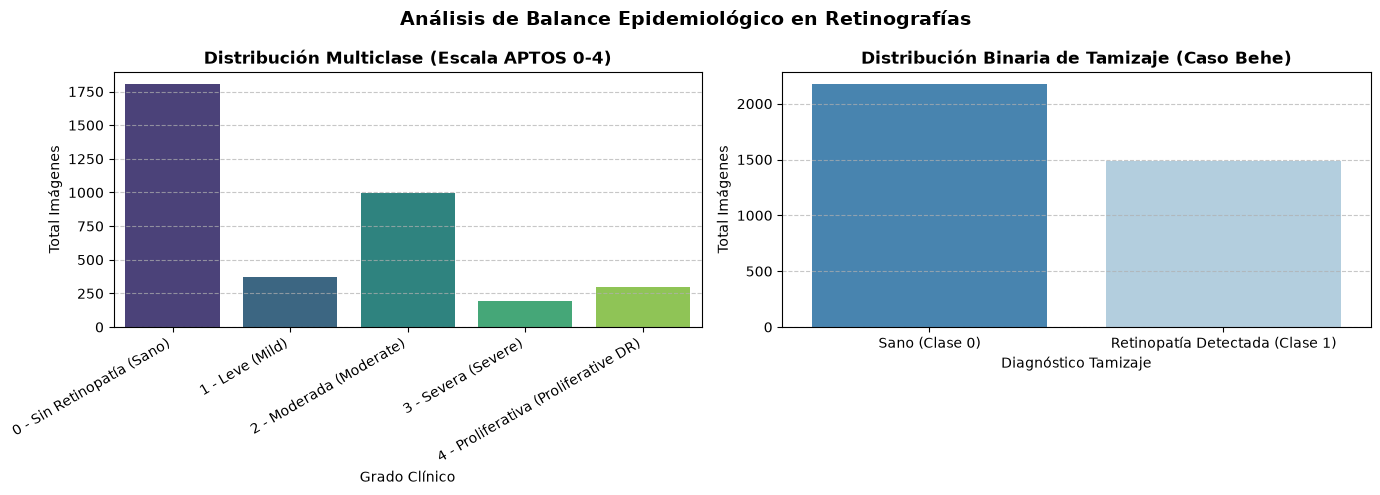

In [43]:
# 5. Visualización gráfica del desbalance de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica Multiclase
sns.barplot(x=df_dist_5['Grado Clínico'], y=df_dist_5['Total Imágenes'], ax=axes[0], palette="viridis")
axes[0].set_title("Distribución Multiclase (Escala APTOS 0-4)", fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfica Binaria
sns.barplot(x=df_dist_bin['Diagnóstico Tamizaje'], y=df_dist_bin['Total Imágenes'], ax=axes[1], palette="Blues_r")
axes[1].set_title("Distribución Binaria de Tamizaje (Caso Behe)", fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle("Análisis de Balance Epidemiológico en Retinografías", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Inspección Visual de Retinografías por Grado Clínico (5 Categorías)

Analizaremos una muestra representativa de cada una de las 5 categorías de severidad diagnóstica. Observe cómo a medida que se incrementa el grado de retinopatía, comienzan a ser visibles lesiones microvasculares como **microaneurismas**, **hemorragias en llama**, **exudados duros** y **neovascularización**.

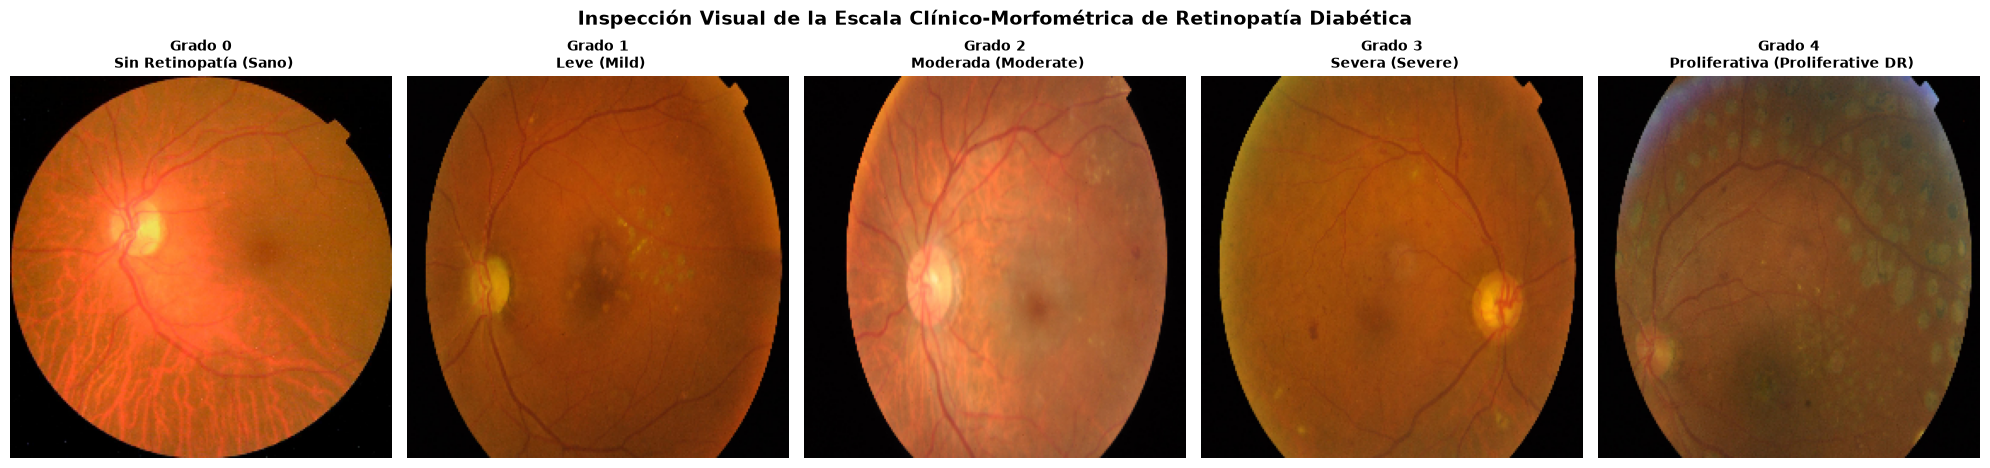

In [44]:
# Muestreo estocástico de 1 imagen por cada uno de los 5 grados clínicos
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for grado in range(5):
    # Filtrar el DataFrame por el grado actual y seleccionar una muestra aleatoria
    muestra = df_clinico[df_clinico['diagnosis'] == grado].sample(1, random_state=42).iloc[0]

    # Cargar la imagen original desde el disco
    img_bytes = tf.io.read_file(muestra['filepath'])
    img_tensor = tf.io.decode_png(img_bytes, channels=3)
    img_tensor = tf.image.resize(img_tensor, [224, 224])

    # Renderizado en la cuadrícula
    axes[grado].imshow(img_tensor.numpy().astype("uint8"))
    axes[grado].set_title(f"Grado {grado}\n{NOMBRES_5_CLASES[grado].split('-')[1]}", fontsize=10, fontweight='bold')
    axes[grado].axis('off')

plt.suptitle("Inspección Visual de la Escala Clínico-Morfométrica de Retinopatía Diabética", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Validación Práctica del Pipeline Dinámico (`tf.data.Dataset`)

Para verificar que nuestro pipeline dinámico está procesando correctamente las imágenes e inyectando los tensores al entorno de entrenamiento, extraeremos **un solo lote (batch)** del conjunto `train_dataset` mediante la instrucción `.take(1)`.

Verificaremos:
1. Las dimensiones del tensor de imágenes recibidas por la red: `(BATCH_SIZE, 224, 224, 3)`.
2. Las etiquetas binarias mapeadas ($0$ para Sano y $1$ para Presencia de Retinopatía).

=== ANATOMÍA DEL TENSOR RECIBIDO POR EL PIPELINE DINÁMICO ===
Forma del tensor de imágenes (Batch, Alto, Ancho, Canales): (32, 224, 224, 3)
Forma del tensor de etiquetas binarias: (32,)
Tipo de dato de la imagen: <dtype: 'float32'>
Primeras 8 etiquetas binarias del lote: [0 0 1 0 0 0 1 0]


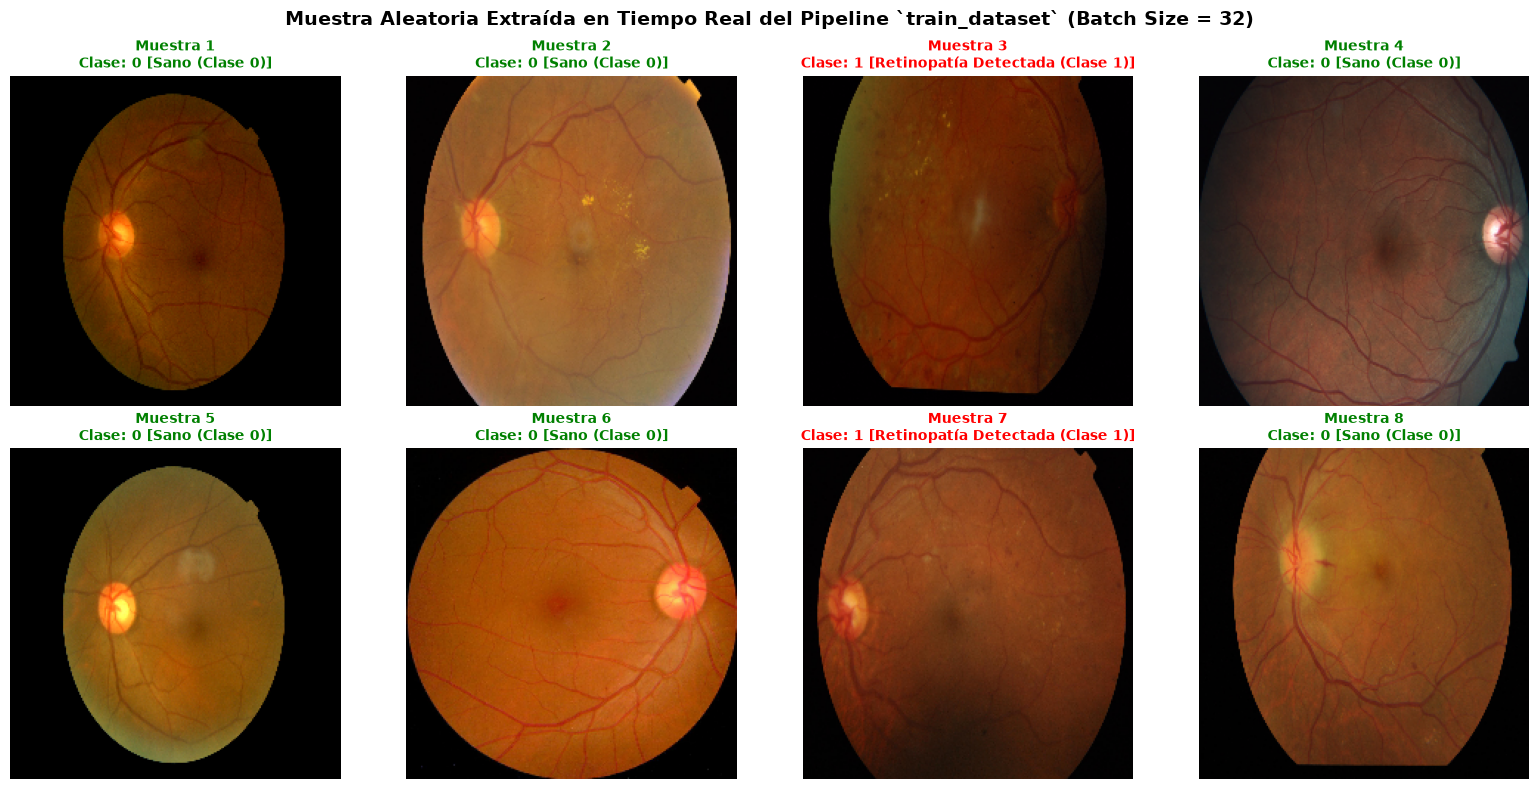

In [45]:
# Extraemos UN LOTE (Batch) del pipeline de entrenamiento dinámico
for lote_imagenes, lote_etiquetas in train_dataset.take(1):
    print("=== ANATOMÍA DEL TENSOR RECIBIDO POR EL PIPELINE DINÁMICO ===")
    print(f"Forma del tensor de imágenes (Batch, Alto, Ancho, Canales): {lote_imagenes.shape}")
    print(f"Forma del tensor de etiquetas binarias: {lote_etiquetas.shape}")
    print(f"Tipo de dato de la imagen: {lote_imagenes.dtype}")
    print(f"Primeras 8 etiquetas binarias del lote: {lote_etiquetas.numpy()[:8]}")
    break

# Visualización de las primeras 8 imágenes contenidas dentro del lote extraído
plt.figure(figsize=(16, 8))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    # Convertimos el tensor flotante a entero de 8 bits para Matplotlib
    img_array = lote_imagenes[i].numpy().astype("uint8")
    etiqueta = lote_etiquetas[i].numpy()

    plt.imshow(img_array)
    color_titulo = "green" if etiqueta == 0 else "red"
    plt.title(f"Muestra {i+1}\nClase: {etiqueta} [{NOMBRES_BINARIOS[etiqueta]}]",
              color=color_titulo, fontweight='bold', fontsize=10)
    plt.axis("off")

plt.suptitle("Muestra Aleatoria Extraída en Tiempo Real del Pipeline `train_dataset` (Batch Size = 32)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Bloque 3: Construcción y Evaluación de la CNN Manual Base (Modelo Sin Regularizar)

## 1. Diseño Arquitectónico y Jerarquía de Extracción
En este bloque diseñaremos nuestra primera Red Neuronal Convolucional (CNN) desde cero utilizando la **API Funcional de Keras**. La arquitectura sigue el patrón clásico de extracción de características piramidal:

1. **Preprocesamiento:** Escalamiento de píxeles $[0, 255] \rightarrow [0, 1]$ mediante `Rescaling(1./255)`.
2. **Crecimiento Jerárquico de Filtros ($32 \rightarrow 64 \rightarrow 128$):** Las capas convolucionales iniciales extraen bordes geométricos y gradientes de color básicos de la retina. Conforme la red profundiza, extrae patrones morfológicos más abstractos (parches vasculares, tonalidades anómalas).
3. **Reducción Espacial (`MaxPooling2D`):** Comprime las dimensiones de alto y ancho a la mitad en cada bloque, otorgando cierta invariancia a la traslación y reduciendo la carga computacional.
4. **Cabeza Clasificadora:** Aplanado del tensor 3D a un vector 1D (`Flatten`), seguido de una capa densa intermedia y una neurona de salida con activación `sigmoid` para estimar la probabilidad de presencia de retinopatía ($0$ = Sano, $1$ = Retinopatía).

**Propósito Pedagógico:** Este modelo base **no incluye regularización** (sin Dropout ni Data Augmentation). Esto nos permitirá diagnosticar el comportamiento natural de sobreajuste (*overfitting*) al entrenar con imágenes médicas complejas y reducidas.

In [46]:
import keras
from keras import layers


In [47]:
# 1. Definición del tensor de entrada (imágenes de 224x224x3)
inputs = keras.Input(shape=(224, 224, 3), name="Input_Retinografia")

# 2. Normalización de píxeles al rango [0, 1]
x = layers.Rescaling(1./255, name="Normalizacion_Pixeles")(inputs)

# Bloque Convolucional 1: Detección de bajo nivel
x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="same", name="Conv_1")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="Max_Pool_1")(x)

# Bloque Convolucional 2: Detección de patrones intermedios
x = layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding="same", name="Conv_2")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="Max_Pool_2")(x)

# Bloque Convolucional 3: Detección de patrones complejos / sintomáticos
x = layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding="same", name="Conv_3")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="Max_Pool_3")(x)

# Cabeza Clasificadora (MLP)
x = layers.Flatten(name="Aplanado_Volumen")(x)
x = layers.Dense(64, activation="relu", name="Capa_Densa_Intermedia")(x)
outputs = layers.Dense(1, activation="sigmoid", name="Diagnostico_Binario")(x)

# Ensamble del modelo
model_manual_base = keras.Model(inputs=inputs, outputs=outputs, name="CNN_Manual_Base")

# 3. Compilación del modelo con métricas diagnósticas
model_manual_base.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

# Resumen de arquitectura y conteo de parámetros
model_manual_base.summary()

Model: "CNN_Manual_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Retinografia (InputLayer) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Normalizacion_Pixeles           │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_1 (MaxPooling2D)       │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_2 (MaxPooling2D)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_3 (MaxPooling2D)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado_Volumen (Flatten)      │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Densa_Intermedia (Dense)   │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Diagnostico_Binario (Dense)     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,515,905 (24.86 MB)

 Trainable params: 6,515,905 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

## 2. Entrenamiento del Modelo Base
Entrenaremos la CNN manual durante un máximo de **15 épocas**. Utilizaremos la función `obtener_callbacks_clinicos("manual_base")` definida en el Bloque 1 para inyectar `EarlyStopping` y `ModelCheckpoint`.

Observaremos en tiempo real cómo divergen las métricas de entrenamiento respecto a las de validación.

In [48]:
# Invocación de callbacks específicos para este experimento
callbacks_base = obtener_callbacks_clinicos("manual_base")

print("--- Iniciando Entrenamiento de la CNN Manual Base ---")
history_manual_base = model_manual_base.fit(
    train_dataset,
    epochs=15,
    validation_data=val_dataset,
    callbacks=callbacks_base
)

--- Iniciando Entrenamiento de la CNN Manual Base ---


c:\Users\rodri\OneDrive - Universidad Iberoamericana León\Clases\7to Semestre\ML III\ml3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7850 - auc: 0.8798 - loss: 0.4202
Epoch 1: val_loss improved from None to 0.29203, saving model to mejor_modelo_retinopatia_manual_base.keras

Epoch 1: finished saving model to mejor_modelo_retinopatia_manual_base.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.7850 - auc: 0.8798 - loss: 0.4202 - val_accuracy: 0.8597 - val_auc: 0.9423 - val_loss: 0.2920
Epoch 2/15
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8230 - auc: 0.9133 - loss: 0.3584
Epoch 2: val_loss did not improve from 0.29203
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.8229 - auc: 0.9131 - loss: 0.3586 - val_accuracy: 0.8689 - val_auc: 0.9448 - val_loss: 0.3114
Epoch 3/15
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8449 - auc: 0.9245 - loss: 0.3363
Epoch 3: val_loss did not improve from 0.29203
81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.8451 - auc: 0.9246 - loss: 0.3361 - val_accuracy: 0.8324 - val_auc: 0.9

## 3. Diagnóstico de Desempeño Clínico y Análisis de Overfitting
Visualizaremos las curvas de aprendizaje para diagnosticar la capacidad de generalización del modelo.

En problemas de diagnóstico médico, el sobreajuste es evidente cuando la pérdida de entrenamiento (`train_loss`) continúa descendiendo mientras que la pérdida de validación (`val_loss`) estanca su progreso o comienza a incrementarse, indicando que la red está **memorizando ruido específico de los pacientes de entrenamiento** en lugar de aprender características morfológicas universales de la retinopatía.

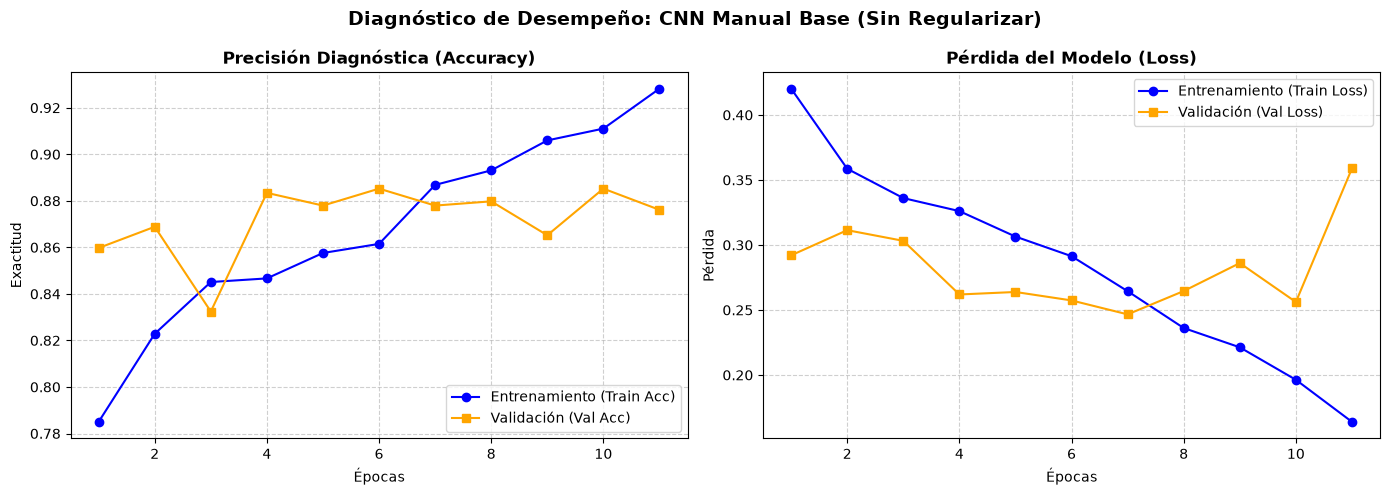

In [49]:
import matplotlib.pyplot as plt

# Extraer métricas del historial de entrenamiento
acc = history_manual_base.history['accuracy']
val_acc = history_manual_base.history['val_accuracy']
loss = history_manual_base.history['loss']
val_loss = history_manual_base.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Visualización gráfica comparativa
plt.figure(figsize=(14, 5))

# Gráfica 1: Exactitud (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento (Train Acc)', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Validación (Val Acc)', marker='s', color='orange')
plt.title('Precisión Diagnóstica (Accuracy)', fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfica 2: Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento (Train Loss)', marker='o', color='blue')
plt.plot(epochs_range, val_loss, label='Validación (Val Loss)', marker='s', color='orange')
plt.title('Pérdida del Modelo (Loss)', fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Diagnóstico de Desempeño: CNN Manual Base (Sin Regularizar)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Evaluación del Modelo Base en el Dataset de Prueba (Test Set)

Una vez completado el entrenamiento, debemos medir la capacidad de generalización del modelo sobre el conjunto de prueba ciego (`test_dataset`). A diferencia del conjunto de validación (utilizado para ajustar la parada temprana), el conjunto de prueba representa pacientes nuevos no vistos durante la fase de optimización.

Para la toma de decisiones clínicas en el **Proyecto Behe**, no basta con medir la exactitud global (*Accuracy*). Construiremos una **Matriz de Confusión** para descomponer las predicciones en:
* **Verdaderos Negativos ($TN$):** Pacientes sanos clasificados correctamente como Sanos ($0$).
* **Falsos Positivos ($FP$):** Pacientes sanos clasificados erróneamente con Retinopatía ($1$).
* **Falsos Negativos ($FN$):** Pacientes enfermos clasificados erróneamente como Sanos ($0$).
* **Verdaderos Positivos ($TP$):** Pacientes enfermos clasificados correctamente con Retinopatía ($1$).

=== RENDIMIENTO GLOBAL EN TEST SET ===
Pérdida (Test Loss):     0.3505
Exactitud (Accuracy):    83.45%
Área Bajo la Curva AUC:  0.9262



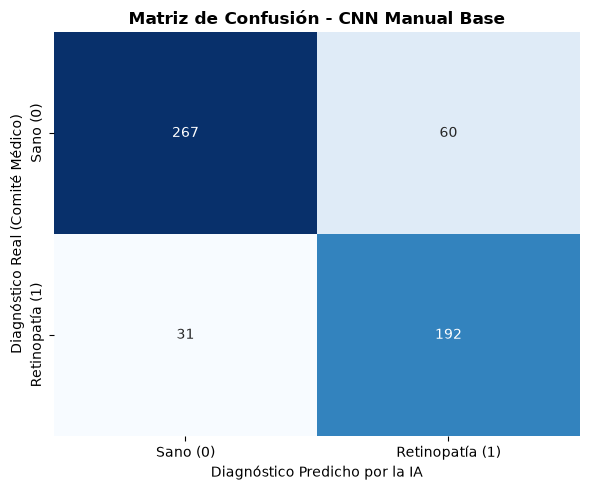

=== DESGLOSE DE MÉTRICAS DE DESEMPEÑO ===
Verdaderos Negativos (TN): 267
Falsos Positivos (FP):     60
Falsos Negativos (FN):     31  <-- ¡Riesgo Clínico!
Verdaderos Positivos (TP): 192

Exactitud (Accuracy):      83.45%
Sensibilidad (Recall):     86.10%
Especificidad:             81.65%
Precisión Diagnóstica:     76.19%


In [50]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Evaluación global en Test Set mediante el método de Keras
loss_test, acc_test, auc_test = model_manual_base.evaluate(test_dataset, verbose=0)
print(f"=== RENDIMIENTO GLOBAL EN TEST SET ===")
print(f"Pérdida (Test Loss):     {loss_test:.4f}")
print(f"Exactitud (Accuracy):    {acc_test * 100:.2f}%")
print(f"Área Bajo la Curva AUC:  {auc_test:.4f}\n")

# 2. Extracción de etiquetas reales y probabilidades predichas
y_true = []
y_pred_probs = []

for lote_img, lote_lbl in test_dataset:
    probs = model_manual_base.predict(lote_img, verbose=0)
    y_true.extend(lote_lbl.numpy())
    y_pred_probs.extend(probs.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Umbral estándar de clasificación binaria (0.5)
y_pred = (y_pred_probs > 0.5).astype(int)

# 3. Construcción de la Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Renderizado gráfico de la Matriz de Confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Sano (0)', 'Retinopatía (1)'],
            yticklabels=['Sano (0)', 'Retinopatía (1)'])
plt.title('Matriz de Confusión - CNN Manual Base', fontweight='bold')
plt.xlabel('Diagnóstico Predicho por la IA')
plt.ylabel('Diagnóstico Real (Comité Médico)')
plt.tight_layout()
plt.show()

# 4. Cálculo explícito de Métricas Clínicas
exactitud = (tp + tn) / (tp + tn + fp + fn)
sensibilidad = tp / (tp + fn)  # Sensitivity / Recall
especificidad = tn / (tn + fp)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0

print(f"=== DESGLOSE DE MÉTRICAS DE DESEMPEÑO ===")
print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP):     {fp}")
print(f"Falsos Negativos (FN):     {fn}  <-- ¡Riesgo Clínico!")
print(f"Verdaderos Positivos (TP): {tp}\n")
print(f"Exactitud (Accuracy):      {exactitud * 100:.2f}%")
print(f"Sensibilidad (Recall):     {sensibilidad * 100:.2f}%")
print(f"Especificidad:             {especificidad * 100:.2f}%")
print(f"Precisión Diagnóstica:     {precision * 100:.2f}%")

## 5. Discusión de Métricas Clínicas y Responsabilidad Ética

En aplicaciones industriales convencionales (como la clasificación de imágenes de comercio electrónico), la métrica primaria suele ser la **Exactitud (Accuracy)**. Sin embargo, en el desarrollo de sistemas médicos dentro del **Proyecto Behe**, evaluar un modelo basándonos únicamente en Accuracy representa un sesgo ético y metodológico grave.

### Análisis Formativo de Métricas

1. **Exactitud ($Accuracy$):**
   $$Exactitud = \frac{TP + TN}{TP + TN + FP + FN}$$
   Mide la proporción total de predicciones correctas. Si un dataset médico tuviera un $90\%$ de pacientes sanos y un $10\%$ con patología, un clasificador trivial que prediga "Sano" a todo el mundo obtendría un $90\%$ de exactitud sin haber aprendido ningún patrón.

2. **Sensibilidad ($Sensibilidad / Recall$):**
   $$Sensibilidad = \frac{TP}{TP + FN}$$
   Mide la capacidad del modelo para identificar correctamente a los pacientes **realmente enfermos**.

### El Dilema Ético en el Tamizaje Primario (Falsos Negativos vs. Falsos Positivos)

* **Impacto de un Falso Positivo ($FP$):** Un paciente sano es etiquetado erróneamente con retinopatía. El costo social es la ansiedad temporal del paciente y la realización de un estudio confirmatorio secundario con un oftalmólogo.
* **Impacto de un Falso Negativo ($FN$):** Un paciente con retinopatía es etiquetado erróneamente como "Sano". Al no recibir seguimiento oportuno, la patología vascular progresará irreversiblemente hacia la **ceguera**.

> **Principio de Diseño Clínico en Behe:** En un algoritmo de tamizaje poblacional, el objetivo primario de ingeniería debe ser **maximizar la Sensibilidad**, asegurando que la tasa de Falsos Negativos ($FN$) sea lo más cercana a cero posible.

## 6. Pipeline de Inferencia Individual sobre una Retinografía
Para simular el despliegue del modelo en un centro de salud comunitario, probaremos el funcionamiento de la red ante un caso clínico individual.

### Regla de Dimensión del Tensor
Las capas de Keras procesan imágenes en lotes (*batches*) de forma cuadridimensional: `(Batch, Alto, Ancho, Canales)`. Al predecir una sola fotografía de $224 \times 224 \times 3$, debemos expandir artificialmente el tensor mediante `tf.expand_dims(img, axis=0)` para generar la forma `(1, 224, 224, 3)` exigida por `model.predict()`.

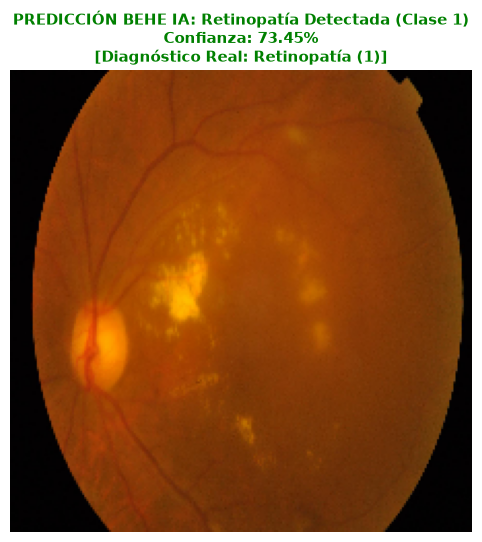

In [51]:
# 1. Extraemos una sola muestra del conjunto de prueba ciego
n=2
for lote_imagenes, lote_etiquetas in test_dataset.take(1):
    img_individual = lote_imagenes[n]
    etiqueta_real = lote_etiquetas[n].numpy()
    break

# 2. Expansión de dimensiones para simular un lote unitario (1, 224, 224, 3)
img_tensor_batch = tf.expand_dims(img_individual, axis=0)

# 3. Inferencia con el modelo entrenado
prediccion_raw = model_manual_base.predict(img_tensor_batch, verbose=0)
probabilidad_retinopatia = prediccion_raw[0][0]

# 4. Interpretación del umbral de decisión (Sigmoide)
UMBRAL = 0.5
if probabilidad_retinopatia > UMBRAL:
    diagnostico_ia = "Retinopatía Detectada (Clase 1)"
    confianza = probabilidad_retinopatia * 100
else:
    diagnostico_ia = "Sin Retinopatía / Sano (Clase 0)"
    confianza = (1 - probabilidad_retinopatia) * 100

diagnostico_real_txt = "Retinopatía (1)" if etiqueta_real == 1 else "Sano (0)"

# 5. Visualización del caso clínico e inferencia de la IA
plt.figure(figsize=(6, 6))
plt.imshow(img_individual.numpy().astype("uint8"))

# Color del título: Verde si el diagnóstico fue acertado, Rojo si falló
es_correcto = (probabilidad_retinopatia > UMBRAL) == (etiqueta_real == 1)
color_titulo = "green" if es_correcto else "red"

plt.title(f"PREDICCIÓN BEHE IA: {diagnostico_ia}\n"
          f"Confianza: {confianza:.2f}%\n"
          f"[Diagnóstico Real: {diagnostico_real_txt}]",
          color=color_titulo, fontweight='bold', fontsize=11)
plt.axis("off")
plt.show()

# Bloque 4: Regularización mediante Aumento de Datos (Data Augmentation) y Dropout

## 1. Fundamentos de Regularización en Visión Médica
En el Bloque 3 diagnosticamos el comportamiento natural de una red convolucional profunda: la tendencia al **sobreajuste (overfitting)**. La red comenzó a memorizar artefactos específicos de los pacientes de entrenamiento (color del fondo ocular, intensidad del flash de la cámara) en lugar de aprender características morfológicas universales de la retinopatía diabética.

Para forzar a la red a aprender representaciones robustas e invariantes, implementaremos dos técnicas complementarias de regularización:

1. **Aumento de Datos Clínico (Data Augmentation):**
   Genera variaciones sintéticas en tiempo real sobre el lote de entrenamiento mediante transformaciones geométricas estocásticas (volteos horizontales/verticales, rotaciones leves y zooms graduados).
   * *Criterio Clínico:* En visión médica, el aumento de datos debe ser riguroso. Evitaremos distorsiones cromáticas o deformaciones extremas que puedan destruir o alterar la apariencia sintomática de microaneurismas, exudados duros o neovascularización.

2. **Capa de Abandono (Dropout):**
   Inyectaremos un `Dropout(0.4)` antes de la cabeza clasificadora denso. Durante cada iteración del entrenamiento, apaga aleatoriamente el $40\%$ de las neuronas, rompiendo la co-adaptación de pesos y obligando al sistema a desarrollar vías de inferencia redundantes y robustas.

> **Comportamiento en Keras 3:** Las capas de `DataAugmentation` y `Dropout` se activan únicamente durante el entrenamiento (`model.fit()`). Durante la evaluación y la inferencia (`evaluate()` y `predict()`), Keras las desactiva automáticamente para procesar la imagen clínica real sin alteración.

In [52]:
import keras
from keras import layers

# =====================================================================
# 1. PIPELINE DE AUMENTO DE DATOS CLÍNICO (SEQUENTIAL)
# =====================================================================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", name="Volteo_Aleatorio"),
    layers.RandomRotation(0.08, fill_mode="nearest", name="Rotacion_Clinica_Leve"),
    layers.RandomZoom(0.08, fill_mode="nearest", name="Zoom_Focal_Leve")
], name="Pipeline_Data_Augmentation")


# =====================================================================
# 2. CONSTRUCCIÓN DE LA CNN MANUAL REGULARIZADA (API FUNCIONAL)
# =====================================================================
inputs = keras.Input(shape=(224, 224, 3), name="Input_Retinografia")

# Paso A: Aplicación de Data Augmentation
x = data_augmentation(inputs)

# Paso B: Normalización de píxeles [0, 255] -> [0, 1]
x = layers.Rescaling(1./255, name="Normalizacion_Pixeles")(x)

# Bloque Convolucional 1
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="Conv_1")(x)
x = layers.MaxPooling2D((2, 2), name="Max_Pool_1")(x)

# Bloque Convolucional 2
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="Conv_2")(x)
x = layers.MaxPooling2D((2, 2), name="Max_Pool_2")(x)

# Bloque Convolucional 3
x = layers.Conv2D(128, (3, 3), activation="relu", padding="same", name="Conv_3")(x)
x = layers.MaxPooling2D((2, 2), name="Max_Pool_3")(x)

# Cabeza Clasificadora con Dropout Preventivo
x = layers.Flatten(name="Aplanado_Volumen")(x)
x = layers.Dropout(0.4, name="Regularizacion_Dropout")(x)  # Desactiva 40% de conexiones
x = layers.Dense(64, activation="relu", name="Capa_Densa_Intermedia")(x)
outputs = layers.Dense(1, activation="sigmoid", name="Diagnostico_Binario")(x)

# Ensamble del modelo regularizado
model_manual_regularizado = keras.Model(
    inputs=inputs, outputs=outputs, name="CNN_Manual_Regularizada"
)

# Compilación con misma tasa de aprendizaje para comparación directa
model_manual_regularizado.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

model_manual_regularizado.summary()

Model: "CNN_Manual_Regularizada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Retinografia (InputLayer) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pipeline_Data_Augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Normalizacion_Pixeles           │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_1 (MaxPooling2D)       │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_2 (MaxPooling2D)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_3 (MaxPooling2D)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado_Volumen (Flatten)      │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Regularizacion_Dropout          │ (None, 100352)         │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Densa_Intermedia (Dense)   │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Diagnostico_Binario (Dense)     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,515,905 (24.86 MB)

 Trainable params: 6,515,905 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

## 2. Entrenamiento de la CNN Regularizada
Entrenaremos la red durante 15 épocas utilizando los callbacks específicos para registrar y almacenar la mejor iteración (`mejor_modelo_retinopatia_manual_regularizado.keras`).

Observaremos cómo la pérdida de entrenamiento y la de validación avanzan de forma simétrica, reduciendo la brecha de sobreajuste.

In [53]:
# Callbacks independientes para el modelo regularizado
callbacks_regularizado = obtener_callbacks_clinicos("manual_regularizado")

print("--- Iniciando Entrenamiento de la CNN Manual Regularizada ---")
history_manual_regularizado = model_manual_regularizado.fit(
    train_dataset,
    epochs=15,
    validation_data=val_dataset,
    callbacks=callbacks_regularizado
)

--- Iniciando Entrenamiento de la CNN Manual Regularizada ---


c:\Users\rodri\OneDrive - Universidad Iberoamericana León\Clases\7to Semestre\ML III\ml3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.7495 - auc: 0.8300 - loss: 0.4967
Epoch 1: val_loss improved from None to 0.39502, saving model to mejor_modelo_retinopatia_manual_regularizado.keras

Epoch 1: finished saving model to mejor_modelo_retinopatia_manual_regularizado.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 22s 268ms/step - accuracy: 0.7495 - auc: 0.8300 - loss: 0.4967 - val_accuracy: 0.8233 - val_auc: 0.9205 - val_loss: 0.3950
Epoch 2/15
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8160 - auc: 0.8901 - loss: 0.3973
Epoch 2: val_loss improved from 0.39502 to 0.32262, saving model to mejor_modelo_retinopatia_manual_regularizado.keras

Epoch 2: finished saving model to mejor_modelo_retinopatia_manual_regularizado.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 197ms/step - accuracy: 0.8158 - auc: 0.8900 - loss: 0.3974 - val_accuracy: 0.8324 - val_auc: 0.9431 - val_loss: 0.3226
Epoch 3/15
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8316 - auc: 0.9071 - loss: 

## 3. Diagnóstico Comparativo de Curvas de Aprendizaje
Graficaremos las curvas de exactitud (*Accuracy*) y pérdida (*Loss*) del modelo regularizado para confirmar si logramos mitigar el sobreajuste observado en el modelo base.

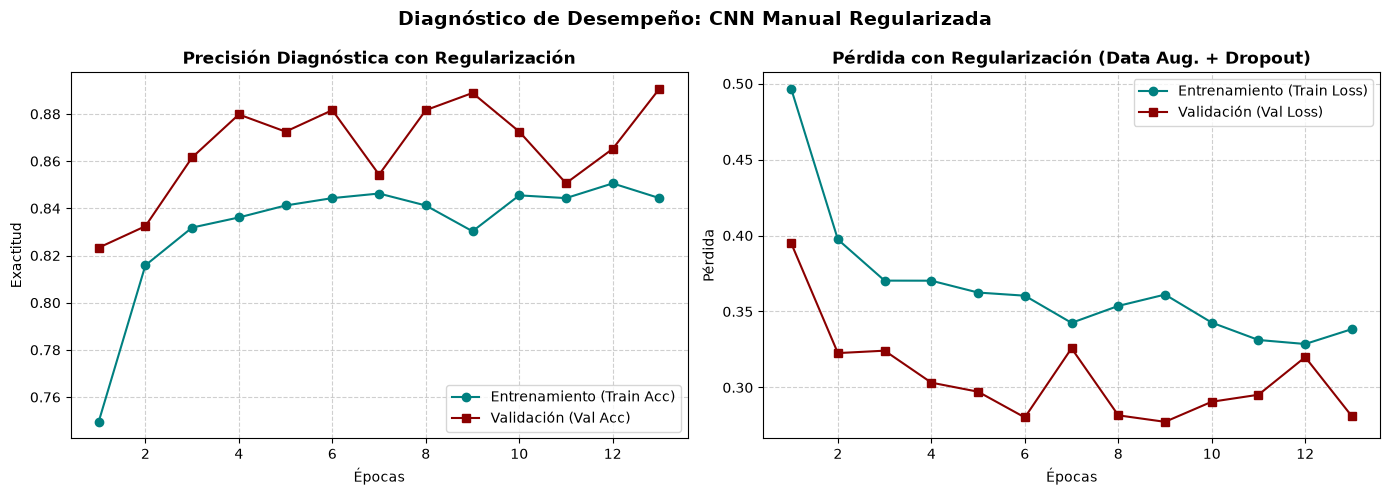

In [54]:
# Extracción de métricas
acc_reg = history_manual_regularizado.history['accuracy']
val_acc_reg = history_manual_regularizado.history['val_accuracy']
loss_reg = history_manual_regularizado.history['loss']
val_loss_reg = history_manual_regularizado.history['val_loss']
epochs_range_reg = range(1, len(acc_reg) + 1)

# Renderizado gráfico
plt.figure(figsize=(14, 5))

# Gráfica 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range_reg, acc_reg, label='Entrenamiento (Train Acc)', marker='o', color='teal')
plt.plot(epochs_range_reg, val_acc_reg, label='Validación (Val Acc)', marker='s', color='darkred')
plt.title('Precisión Diagnóstica con Regularización', fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfica 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range_reg, loss_reg, label='Entrenamiento (Train Loss)', marker='o', color='teal')
plt.plot(epochs_range_reg, val_loss_reg, label='Validación (Val Loss)', marker='s', color='darkred')
plt.title('Pérdida con Regularización (Data Aug. + Dropout)', fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Diagnóstico de Desempeño: CNN Manual Regularizada", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Evaluación en Test Set y Matriz de Confusión Comparativa
Evaluaremos el nuevo modelo sobre el conjunto de prueba ciego (`test_dataset`) para comprobar si la reducción del sobreajuste se traduce en un mejor desempeño clínico real y, de manera crítica, en una **reducción de los Falsos Negativos ($FN$)** con respecto al modelo base (donde obtuvimos $FN = 28$).

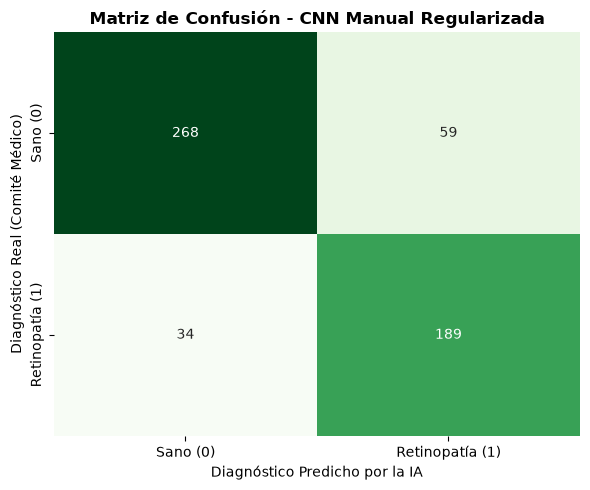

          TABLA COMPARATIVA DE DESEMPEÑO CLÍNICO               
Métrica                     | Base (Bloque 3) | Regularizado (Bloque 4)
----------------------------|-----------------|-----------------------
Exactitud (Accuracy)        | 84.55%          | 83.09%
Área Bajo Curva (AUC)       | 0.9200          | 0.9178
Falsos Negativos (FN)       | 28              | 34  <-- Critico
Falsos Positivos (FP)       | 57              | 59
Sensibilidad (Recall)       | 87.44%          | 84.75%
Especificidad               | 82.57%          | 81.96%


In [55]:
# 1. Evaluación directa en Keras
loss_reg_test, acc_reg_test, auc_reg_test = model_manual_regularizado.evaluate(test_dataset, verbose=0)

# 2. Extracción de predicciones
y_true_reg = []
y_pred_probs_reg = []

for lote_img, lote_lbl in test_dataset:
    probs = model_manual_regularizado.predict(lote_img, verbose=0)
    y_true_reg.extend(lote_lbl.numpy())
    y_pred_probs_reg.extend(probs.flatten())

y_true_reg = np.array(y_true_reg)
y_pred_probs_reg = np.array(y_pred_probs_reg)
y_pred_reg = (y_pred_probs_reg > 0.5).astype(int)

# 3. Matriz de confusión
cm_reg = confusion_matrix(y_true_reg, y_pred_reg)
tn_r, fp_r, fn_r, tp_r = cm_reg.ravel()

# 4. Métricas calculadas
sensibilidad_r = tp_r / (tp_r + fn_r)
especificidad_r = tn_r / (tn_r + fp_r)

# Renderizado gráfico
plt.figure(figsize=(6, 5))
sns.heatmap(cm_reg, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Sano (0)', 'Retinopatía (1)'],
            yticklabels=['Sano (0)', 'Retinopatía (1)'])
plt.title('Matriz de Confusión - CNN Manual Regularizada', fontweight='bold')
plt.xlabel('Diagnóstico Predicho por la IA')
plt.ylabel('Diagnóstico Real (Comité Médico)')
plt.tight_layout()
plt.show()

# 5. Tabla comparativa vs Modelo Base
print("===============================================================")
print("          TABLA COMPARATIVA DE DESEMPEÑO CLÍNICO               ")
print("===============================================================")
print(f"Métrica                     | Base (Bloque 3) | Regularizado (Bloque 4)")
print(f"----------------------------|-----------------|-----------------------")
print(f"Exactitud (Accuracy)        | 84.55%          | {acc_reg_test * 100:.2f}%")
print(f"Área Bajo Curva (AUC)       | 0.9200          | {auc_reg_test:.4f}")
print(f"Falsos Negativos (FN)       | 28              | {fn_r}  <-- Critico")
print(f"Falsos Positivos (FP)       | 57              | {fp_r}")
print(f"Sensibilidad (Recall)       | 87.44%          | {sensibilidad_r * 100:.2f}%")
print(f"Especificidad               | 82.57%          | {especificidad_r * 100:.2f}%")
print("===============================================================")

# Bloque 5: Aprendizaje por Transferencia (Transfer Learning) Colectivo con EfficientNetV2S


## 1. Fundamentos de Transfer Learning en Visión Médica
En los Bloques 3 y 4 diseñamos y regularizamos una arquitectura convolucional manual entrenada desde cero. Aunque la regularización redujo el sobreajuste, entrenar filtros desde ceros con datasets reducidos limita la capacidad de abstracción de la red.

En entornos de producción médica real para el **Proyecto Behe**, el estándar de la industria es aplicar **Aprendizaje por Transferencia (Transfer Learning)** en su modalidad de **Extracción de Características (Feature Extraction)**.

### ¿Por qué utilizar EfficientNetV2S?
1. **Eficiencia Paramétrica y Escalado Balanceado:** EfficientNetV2S optimiza la relación entre profundidad, ancho y resolución, logrando muy buen desempeño con menor costo computacional que arquitecturas más pesadas.
2. **Transferencia de Conocimiento:** Reutilizaremos los pesos matemáticos preentrenados en **ImageNet** (más de 1.4 millones de imágenes). Las capas convolucionales profundas ya aprendieron a detectar bordes, texturas y geometrías complejas que sirven como extractores de rasgos universales para retinografías.

### Reglas de Ingeniería para Transfer Learning en Keras 3
* **Congelamiento de la Base (`base_model.trainable = False`):** Bloquea los pesos del esqueleto convolucional preentrenado. El optimizador no modificará estos filtros.
* **Preprocesamiento Obligatorio (`efficientnet_v2.preprocess_input`):** Ajusta la escala cromática de los píxeles de entrada a la distribución esperada por EfficientNetV2S.
* **Sustitución de la Cabeza Clasificadora:** Eliminamos la capa final de 1,000 clases de ImageNet e inyectamos una capa `GlobalAveragePooling2D` seguida de nuestra neurona de salida con activación `sigmoid` para la clasificación binaria de retinopatía.

In [73]:
import keras
from keras import layers

# =====================================================================
# 1. CARGA Y CONGELAMIENTO DEL ESQUELETO PREENTRENADO (EFFICIENTNETV2S)
# =====================================================================
print("Cargando esqueleto convolucional EfficientNetV2S preentrenado en ImageNet...")
base_model = keras.applications.EfficientNetV2S(
    weights="imagenet",
    include_top=False,  # Corta la cabeza clasificadora original de 1,000 clases
    input_shape=(224, 224, 3)
)

# REGLA 1: Congelar pesos del backbone
base_model.trainable = False

# REGLA 2: Preprocesamiento nativo de la arquitectura EfficientNetV2S
preprocess_input = keras.applications.efficientnet_v2.preprocess_input


# =====================================================================
# 2. CONSTRUCCIÓN DEL GRAFO FUNCIONAL DE TRANSFER LEARNING
# =====================================================================
inputs = keras.Input(shape=(224, 224, 3), name="Input_Retinografia")

# Paso A: Data Augmentation validado en Bloque 4
x = data_augmentation(inputs)

# Paso B: Preprocesamiento de color específico de EfficientNetV2S
x = preprocess_input(x)

# Paso C: Inferencia sobre la base congelada (training=False mantiene BatchNormalization en modo inferencia)
x = base_model(x, training=False)

# Paso D: Compactación espacial inteligente (GAP en lugar de Flatten)
x = layers.GlobalAveragePooling2D(name="Compactacion_Espacial")(x)

# Paso E: Cabeza clasificadora médica
x = layers.Dropout(0.3, name="Regularizacion_Cabeza")(x)
outputs = layers.Dense(1, activation="sigmoid", name="Diagnostico_Transfer")(x)

# Ensamble del modelo de Transfer Learning
model_transfer = keras.Model(
    inputs=inputs, outputs=outputs, name="CNN_EfficientNetV2S_Transfer"
)

# Compilación
model_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

model_transfer.summary()

Cargando esqueleto convolucional EfficientNetV2S preentrenado en ImageNet...


Model: "CNN_EfficientNetV2S_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Retinografia (InputLayer) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pipeline_Data_Augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Compactacion_Espacial           │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Regularizacion_Cabeza (Dropout) │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Diagnostico_Transfer (Dense)    │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,332,641 (77.56 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

In [74]:
import numpy as np

# Callbacks específicos para el modelo de Transfer Learning (EfficientNetV2S)
callbacks_transfer_eff = obtener_callbacks_clinicos("transfer_efficientnetv2s")

print("--- Iniciando Entrenamiento con Transfer Learning (EfficientNetV2S) ---")
history_transfer_eff = model_transfer.fit(
    train_dataset,
    epochs=8,
    validation_data=val_dataset,
    callbacks=callbacks_transfer_eff
)

# Mejor accuracy en entrenamiento y validación
acc_train = history_transfer_eff.history.get("accuracy", [])
acc_val = history_transfer_eff.history.get("val_accuracy", [])

if acc_train:
    i_train = int(np.argmax(acc_train))
    print(f"Max train accuracy: {acc_train[i_train]:.4f} (época {i_train+1})")
else:
    print("No hay accuracy de entrenamiento en history_transfer_eff.")

if acc_val:
    i_val = int(np.argmax(acc_val))
    print(f"Max val accuracy:   {acc_val[i_val]:.4f} (época {i_val+1})")
else:
    print("No hay val_accuracy en history_transfer_eff.")

--- Iniciando Entrenamiento con Transfer Learning (EfficientNetV2S) ---


c:\Users\rodri\OneDrive - Universidad Iberoamericana León\Clases\7to Semestre\ML III\ml3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7831 - auc: 0.8799 - loss: 0.4526
Epoch 1: val_loss improved from None to 0.32484, saving model to mejor_modelo_retinopatia_transfer_efficientnetv2s.keras

Epoch 1: finished saving model to mejor_modelo_retinopatia_transfer_efficientnetv2s.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 315s 4s/step - accuracy: 0.7831 - auc: 0.8799 - loss: 0.4526 - val_accuracy: 0.8670 - val_auc: 0.9496 - val_loss: 0.3248
Epoch 2/8
25/81 ━━━━━━━━━━━━━━━━━━━━ 2:54 3s/step - accuracy: 0.8438 - auc: 0.9103 - loss: 0.3764

KeyboardInterrupt: 

# Bloque 5: Aprendizaje por Transferencia (Transfer Learning) Colectivo con ResNet50V2


In [59]:
import keras
from keras import layers

# =====================================================================
# 1. CARGA Y CONGELAMIENTO DEL ESQUELETO PREENTRENADO (RESNET50V2)
# =====================================================================
print("Cargando esqueleto convolucional ResNet50V2 preentrenado en ImageNet...")
base_model = keras.applications.ResNet50V2(
    weights="imagenet",
    include_top=False,  # Corta la cabeza clasificadora original de 1,000 clases
    input_shape=(224, 224, 3)
)

# REGLA 1: Congelar pesos del backbone
base_model.trainable = False

# REGLA 2: Preprocesamiento nativo de la arquitectura ResNet50V2
preprocess_input = keras.applications.resnet_v2.preprocess_input


# =====================================================================
# 2. CONSTRUCCIÓN DEL GRAFO FUNCIONAL DE TRANSFER LEARNING
# =====================================================================
inputs = keras.Input(shape=(224, 224, 3), name="Input_Retinografia")

# Paso A: Data Augmentation validado en Bloque 4
x = data_augmentation(inputs)

# Paso B: Preprocesamiento de color específico de ResNet50V2 (Escala [-1, 1])
x = preprocess_input(x)

# Paso C: Inferencia sobre la base congelada (training=False mantiene BatchNormalization en modo inferencia)
x = base_model(x, training=False)

# Paso D: Compactación espacial inteligente (GAP en lugar de Flatten)
x = layers.GlobalAveragePooling2D(name="Compactacion_Espacial")(x)

# Paso E: Cabeza clasificadora médica
x = layers.Dropout(0.3, name="Regularizacion_Cabeza")(x)
outputs = layers.Dense(1, activation="sigmoid", name="Diagnostico_Transfer")(x)

# Ensamble del modelo de Transfer Learning
model_transfer = keras.Model(
    inputs=inputs, outputs=outputs, name="CNN_ResNet50V2_Transfer"
)

# Compilación
model_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

model_transfer.summary()

Cargando esqueleto convolucional ResNet50V2 preentrenado en ImageNet...


Model: "CNN_ResNet50V2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Retinografia (InputLayer) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pipeline_Data_Augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Compactacion_Espacial           │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Regularizacion_Cabeza (Dropout) │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Diagnostico_Transfer (Dense)    │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,566,849 (89.90 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

## 2. Entrenamiento Acelerado de la Cabeza Clasificadora
Dado que las 50 capas convolucionales de ResNet50V2 se encuentran congeladas, el optimizador únicamente entrenará **2,049 parámetros** pertenecientes a la capa `Dense` final.

Esto permite que el modelo converja con extrema rapidez (requiriendo únicamente entre 5 y 8 épocas) y sin riesgo de sobreajustar la base de datos.

In [60]:
# Callbacks específicos para el modelo de Transfer Learning
callbacks_transfer = obtener_callbacks_clinicos("transfer_resnet50v2")

print("--- Iniciando Entrenamiento con Transfer Learning (ResNet50V2) ---")
history_transfer = model_transfer.fit(
    train_dataset,
    epochs=8,
    validation_data=val_dataset,
    callbacks=callbacks_transfer
)

--- Iniciando Entrenamiento con Transfer Learning (ResNet50V2) ---
Epoch 1/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.7522 - auc: 0.8301 - loss: 0.5026
Epoch 1: val_loss improved from None to 0.32966, saving model to mejor_modelo_retinopatia_transfer_resnet50v2.keras

Epoch 1: finished saving model to mejor_modelo_retinopatia_transfer_resnet50v2.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 24s 290ms/step - accuracy: 0.7522 - auc: 0.8301 - loss: 0.5026 - val_accuracy: 0.8525 - val_auc: 0.9353 - val_loss: 0.3297
Epoch 2/8
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8545 - auc: 0.9199 - loss: 0.3544
Epoch 2: val_loss improved from 0.32966 to 0.32517, saving model to mejor_modelo_retinopatia_transfer_resnet50v2.keras

Epoch 2: finished saving model to mejor_modelo_retinopatia_transfer_resnet50v2.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 45s 561ms/step - accuracy: 0.8545 - auc: 0.9199 - loss: 0.3544 - val_accuracy: 0.8452 - val_auc: 0.9501 - val_loss: 0.3252
Epoch 3/8
81/81 ━━━━━━━━━━━━

## 3. Diagnóstico de Curvas de Aprendizaje (Transfer Learning)
Graficaremos el comportamiento del modelo para verificar la velocidad de convergencia y la estabilidad del error de validación.

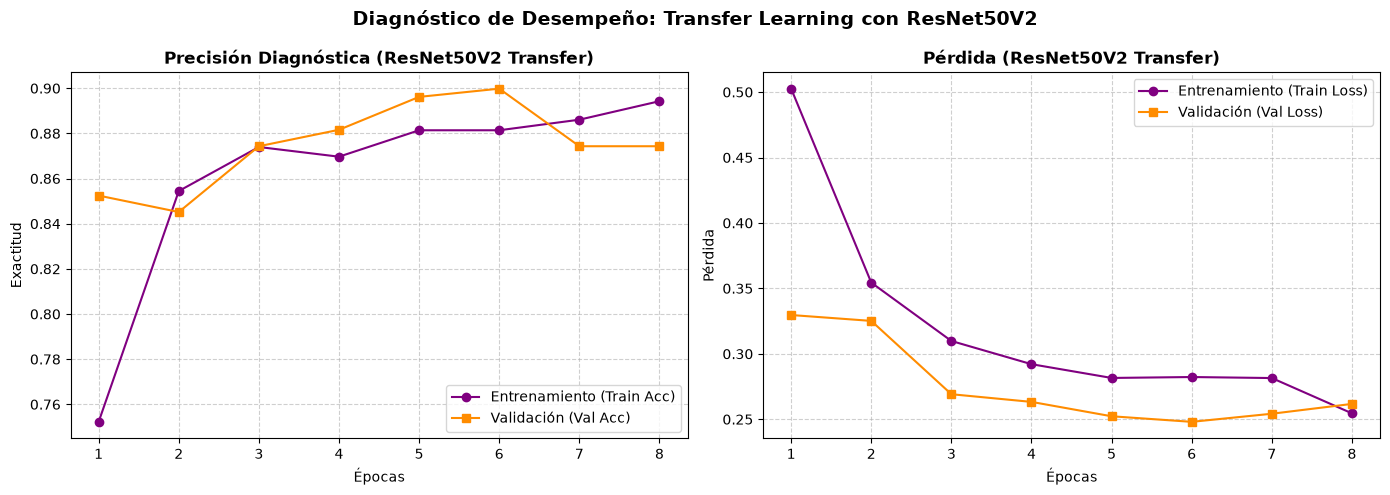

In [61]:
# Extracción de métricas de Transfer Learning
acc_tf = history_transfer.history['accuracy']
val_acc_tf = history_transfer.history['val_accuracy']
loss_tf = history_transfer.history['loss']
val_loss_tf = history_transfer.history['val_loss']
epochs_range_tf = range(1, len(acc_tf) + 1)

# Renderizado gráfico
plt.figure(figsize=(14, 5))

# Gráfica 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range_tf, acc_tf, label='Entrenamiento (Train Acc)', marker='o', color='purple')
plt.plot(epochs_range_tf, val_acc_tf, label='Validación (Val Acc)', marker='s', color='darkorange')
plt.title('Precisión Diagnóstica (ResNet50V2 Transfer)', fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfica 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range_tf, loss_tf, label='Entrenamiento (Train Loss)', marker='o', color='purple')
plt.plot(epochs_range_tf, val_loss_tf, label='Validación (Val Loss)', marker='s', color='darkorange')
plt.title('Pérdida (ResNet50V2 Transfer)', fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Diagnóstico de Desempeño: Transfer Learning con ResNet50V2", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Evaluación en Test Set, Matriz de Confusión y Gran Tabla Comparativa

Evaluaremos el modelo de **Transfer Learning con ResNet50V2** sobre el conjunto de prueba ciego (`test_dataset`).

Generaremos una tabla comparativa global consolidando la evolución del **Proyecto Behe** a través de las tres etapas de desarrollo:
1. **CNN Manual Base** (Bloque 3: Modelo inicial sin regularizar)
2. **CNN Manual Regularizada** (Bloque 4: Data Augmentation + Dropout)
3. **ResNet50V2 Transfer Learning** (Bloque 5: Extracción de características preentrenadas)

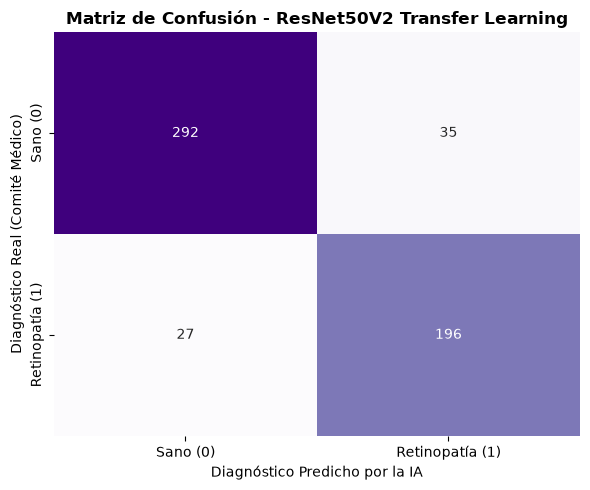

            GRAN TABLA COMPARATIVA DE DESEMPEÑO - PROYECTO BEHE                        
Métrica                     | Bloque 3: Base  | Bloque 4: Regularizado | Bloque 5: ResNet50V2
----------------------------|-----------------|------------------------|-----------------------
Exactitud (Accuracy)        | 83.45%          | 83.09%                 | 88.73%
Área Bajo Curva (AUC)       | 0.9262          | 0.9178                 | 0.9574
Falsos Negativos (FN)       | 31              | 34                     | 27  <-- ¡Impacto!
Falsos Positivos (FP)       | 60              | 59                     | 35
Sensibilidad (Recall)       | 86.10%          | 84.75%                 | 87.89%
Especificidad               | 81.65%          | 81.96%                 | 89.30%


In [62]:
# 1. Evaluación directa en Test Set
loss_tf_test, acc_tf_test, auc_tf_test = model_transfer.evaluate(test_dataset, verbose=0)

# 2. Inferencia sobre Test Set
y_true_tf = []
y_pred_probs_tf = []

for lote_img, lote_lbl in test_dataset:
    probs = model_transfer.predict(lote_img, verbose=0)
    y_true_tf.extend(lote_lbl.numpy())
    y_pred_probs_tf.extend(probs.flatten())

y_true_tf = np.array(y_true_tf)
y_pred_probs_tf = np.array(y_pred_probs_tf)
y_pred_tf = (y_pred_probs_tf > 0.5).astype(int)

# 3. Matriz de confusión
cm_tf = confusion_matrix(y_true_tf, y_pred_tf)
tn_tf, fp_tf, fn_tf, tp_tf = cm_tf.ravel()

# 4. Métricas clínicas calculadas
sensibilidad_tf = tp_tf / (tp_tf + fn_tf)
especificidad_tf = tn_tf / (tn_tf + fp_tf)
precision_tf = tp_tf / (tp_tf + fp_tf) if (tp_tf + fp_tf) > 0 else 0.0

# Renderizado gráfico de la Matriz de Confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Sano (0)', 'Retinopatía (1)'],
            yticklabels=['Sano (0)', 'Retinopatía (1)'])
plt.title('Matriz de Confusión - ResNet50V2 Transfer Learning', fontweight='bold')
plt.xlabel('Diagnóstico Predicho por la IA')
plt.ylabel('Diagnóstico Real (Comité Médico)')
plt.tight_layout()
plt.show()

# 5. Gran Tabla Comparativa Tridimensional
print("=======================================================================================")
print("            GRAN TABLA COMPARATIVA DE DESEMPEÑO - PROYECTO BEHE                        ")
print("=======================================================================================")
print(f"Métrica                     | Bloque 3: Base  | Bloque 4: Regularizado | Bloque 5: ResNet50V2")
print(f"----------------------------|-----------------|------------------------|-----------------------")
print(f"Exactitud (Accuracy)        | {acc_test * 100:.2f}%          | {acc_reg_test * 100:.2f}%                 | {acc_tf_test * 100:.2f}%")
print(f"Área Bajo Curva (AUC)       | {auc_test:.4f}          | {auc_reg_test:.4f}                 | {auc_tf_test:.4f}")
print(f"Falsos Negativos (FN)       | {fn}              | {fn_r}                     | {fn_tf}  <-- ¡Impacto!")
print(f"Falsos Positivos (FP)       | {fp}              | {fp_r}                     | {fp_tf}")
print(f"Sensibilidad (Recall)       | {sensibilidad * 100:.2f}%          | {sensibilidad_r * 100:.2f}%                 | {sensibilidad_tf * 100:.2f}%")
print(f"Especificidad               | {especificidad * 100:.2f}%          | {especificidad_r * 100:.2f}%                 | {especificidad_tf * 100:.2f}%")
print("=======================================================================================")

# Bloque 6: Inteligencia Artificial Explicable (XAI) y Mapas de Activación (Grad-CAM)

## 1. Justificación Clínica, Ética y Arquitectónica
En el desarrollo de soluciones médicas para el **Proyecto Behe**, la precisión diagnóstica no es suficiente. De acuerdo con el enfoque humanista de la Universidad Iberoamericana y los principios de bioética en salud digital, un sistema de IA no debe operar como una "caja negra". Los profesionales de la salud requieren auditar visualmente las razones morfométricas detrás de una predicción antes de determinar un tratamiento o procedimiento quirúrgico.

Para lograr esto, implementaremos **Grad-CAM (Class Activation Mapping mediante Gradientes)** sobre nuestra red **ResNet50V2**.

### Mapeo Arquitectónico de Características
Para extraer el mapa de activación de la última capa convolucional (`conv5_block3_out` en ResNet50V2), debemos conservar la información espacial tridimensional ($7 \times 7 \times 2048$) antes de que la capa `GlobalAveragePooling2D` colapse las coordenadas.

Inyectaremos una **Capa de Identidad (`layers.Activation('linear', name='Identity_Feature_Map')`)** inmediatamente después del esqueleto preentrenado. Esto nos otorgará un punto de anclaje (*hook*) dentro del grafo funcional para extraer activaciones y computar gradientes con respecto a la clase objetivo utilizando el motor de autograd de PyTorch.

In [63]:
# =====================================================================
# 1. RECONSTRUCCIÓN DEL MODELO CON CAPA DE IDENTIDAD PARA GRAD-CAM
# =====================================================================
inputs = keras.Input(shape=(224, 224, 3), name="Input_Retinografia")

# Pipeline de Aumento y Preprocesamiento
x = data_augmentation(inputs)
x = keras.applications.resnet_v2.preprocess_input(x)

# Esqueleto ResNet50V2 Congelado
base_model = keras.applications.ResNet50V2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

# Salida del mapa convolucional base (7x7x2048)
x_conv = base_model(x, training=False)

# CAPA DE IDENTIDAD: Punto de extracción con conservación de coordenadas espaciales
identity_conv = layers.Activation("linear", name="Identity_Feature_Map")(x_conv)

# Cabeza Clasificadora Médica
x = layers.GlobalAveragePooling2D(name="Compactacion_Espacial")(identity_conv)
x = layers.Dropout(0.3, name="Regularizacion_Cabeza")(x)
outputs = layers.Dense(1, activation="sigmoid", name="Diagnostico_Transfer")(x)

# Ensamble del modelo optimizado para XAI
model_resnet_xai = keras.Model(inputs=inputs, outputs=outputs, name="ResNet50V2_GradCAM")

# Compilación
model_resnet_xai.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

print("--- Modelo ResNet50V2 reconfigurado con Capa de Identidad para Grad-CAM ---")
model_resnet_xai.summary()

--- Modelo ResNet50V2 reconfigurado con Capa de Identidad para Grad-CAM ---


Model: "ResNet50V2_GradCAM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Retinografia (InputLayer) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pipeline_Data_Augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Identity_Feature_Map            │ (None, 7, 7, 2048)     │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Compactacion_Espacial           │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Regularizacion_Cabeza (Dropout) │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Diagnostico_Transfer (Dense)    │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,566,849 (89.90 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

## 2. Fundamento Matemático del Algoritmo Grad-CAM
Grad-CAM utiliza la propagación de gradientes hacia atrás (*backpropagation*) para evaluar la importancia de cada mapa de características $A^k$ en la última capa convolucional respecto al puntaje de salida $Y^c$ (previo a la función sigmoide).

1. **Cálculo de Pesos de Importancia ($\alpha_k^c$):** Se calcula el promedio espacial del gradiente mediante *Global Average Pooling*:
$$\alpha_k^c = \frac{1}{Z} \sum_{i} \sum_{j} \frac{\partial Y^c}{\partial A_{i,j}^k}$$

2. **Combinación Lineal y Rectificación (ReLU):** Se genera el mapa de calor ponderando los canales de activación e ignorando los gradientes negativos (aquellos que no contribuyen positivamente a la detección de la patología):
$$L_{\text{Grad-CAM}}^c = \text{ReLU}\left( \sum_{k} \alpha_k^c A^k \right)$$

In [64]:
# =====================================================================
# 2. FUNCIÓN DE EXTRACCIÓN Y GENERACIÓN DE MAPAS DE CALOR (PYTORCH)
# =====================================================================
def generar_gradcam_resnet(modelo, img_array, capa_identidad_nombre="Identity_Feature_Map"):
    """
    Genera el mapa de calor Grad-CAM superpuesto sobre la retinografía original
    utilizando el motor autograd de PyTorch.
    """
    modelo.eval()

    # Grafo intermedio para extraer simultáneamente los mapas convolucionales y la predicción final
    grad_model = keras.Model(
        inputs=modelo.inputs,
        outputs=[modelo.get_layer(capa_identidad_nombre).output, modelo.output]
    )

    # Formateo del tensor de entrada para PyTorch
    input_tensor = torch.tensor(img_array, dtype=torch.float32)
    if input_tensor.dim() == 3:
        input_tensor = input_tensor.unsqueeze(0)

    input_tensor.requires_grad = True

    # 1. Forward Pass
    conv_outputs, predicciones = grad_model(input_tensor, training=False)

    # Mantenimiento de gradientes en tensores no hoja
    conv_outputs.retain_grad()

    # 2. Backward Pass sobre el puntaje de la clase
    clase_score = predicciones[:, 0]
    clase_score.backward()

    # 3. Extracción de gradientes y cálculo de pesos alpha
    grads = conv_outputs.grad
    weights = torch.mean(grads, dim=(0, 1, 2))

    # 4. Suma ponderada de canales de activación
    heatmap = torch.sum(weights * conv_outputs, dim=-1)

    # 5. Aplicación de ReLU y Normalización [0, 1]
    heatmap = torch.relu(heatmap)
    heatmap_max = torch.max(heatmap)
    if heatmap_max > 0:
        heatmap = heatmap / heatmap_max

    # Conversión a NumPy
    heatmap_np = heatmap.squeeze().detach().cpu().numpy()

    return heatmap_np, predicciones.item()

## 3. Auditoría Visual e Inferencia Explicable
Probaremos el algoritmo de explicabilidad seleccionando un caso clínico de prueba del `test_dataset`. Superpondremos la matriz de calor espacial formateada bajo la paleta cromática `JET` sobre la retinografía original para identificar exactamente qué patrones regionales identificó la red.

In [69]:
import cv2

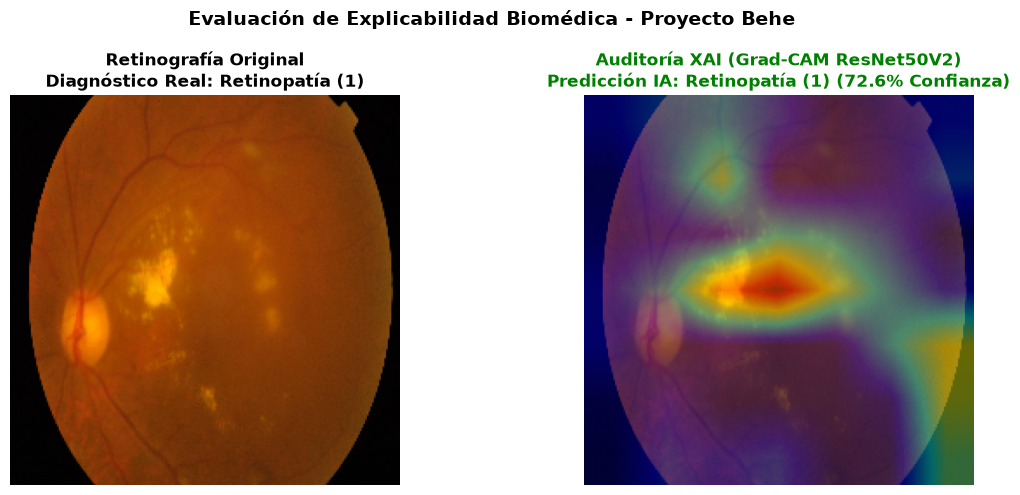

In [70]:
# =====================================================================
# 3. PIPELINE DE SUPERPOSICIÓN CROMÁTICA Y VISUALIZACIÓN
# =====================================================================
# Extracción de una imagen de prueba del test_dataset
n=2  # Índice de la muestra a auditar #2,6,9
for lote_img, lote_lbl in test_dataset.take(1):
    img_muestra = lote_img[n].numpy()
    label_real = lote_lbl[n].numpy()
    break

# Expansión de dimensiones
img_input = np.expand_dims(img_muestra, axis=0)

# Generación del mapa de calor
heatmap, prob_predicha = generar_gradcam_resnet(model_resnet_xai, img_input)

# Post-procesamiento gráfico con OpenCV
img_original_uint8 = img_muestra.astype("uint8")
h, w, _ = img_original_uint8.shape

# Redimensionamiento del mapa de calor a las dimensiones originales de la imagen (224x224)
heatmap_resized = cv2.resize(heatmap, (w, h))
heatmap_uint8 = np.uint8(255 * heatmap_resized)

# Aplicación del mapa de color JET (Azul = Frío/Normal, Rojo = Caliente/Lesión)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Superposición transparente (60% imagen original, 40% mapa de calor)
superposicion = cv2.addWeighted(img_original_uint8, 0.6, heatmap_color, 0.4, 0)

# Renderizado comparativo
plt.figure(figsize=(12, 5))

# Imagen Original
plt.subplot(1, 2, 1)
plt.imshow(img_original_uint8)
txt_real = "Retinopatía (1)" if label_real == 1 else "Sano (0)"
plt.title(f"Retinografía Original\nDiagnóstico Real: {txt_real}", fontweight='bold')
plt.axis("off")

# Explicabilidad Grad-CAM
plt.subplot(1, 2, 2)
plt.imshow(superposicion)
txt_pred = "Retinopatía (1)" if prob_predicha > 0.5 else "Sano (0)"
confianza = prob_predicha * 100 if prob_predicha > 0.5 else (1 - prob_predicha) * 100
color_tit = "green" if (prob_predicha > 0.5) == (label_real == 1) else "red"

plt.title(f"Auditoría XAI (Grad-CAM ResNet50V2)\nPredicción IA: {txt_pred} ({confianza:.1f}% Confianza)",
          color=color_tit, fontweight='bold')
plt.axis("off")

plt.suptitle("Evaluación de Explicabilidad Biomédica - Proyecto Behe", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
# =====================================================================
# 1. FUNCIÓN VECTORIZADA DE GRAD-CAM PARA LOTE COMPLETO (32 IMÁGENES)
# =====================================================================
def generar_gradcam_lote_resnet(modelo, lote_img_array, capa_identidad_nombre="Identity_Feature_Map"):
    """
    Calcula los mapas de calor Grad-CAM de forma vectorizada para un lote de 32 imágenes.
    """
    modelo.eval()

    # Grafo intermedio para extraer activaciones convolucionales y predicciones
    grad_model = keras.Model(
        inputs=modelo.inputs,
        outputs=[modelo.get_layer(capa_identidad_nombre).output, modelo.output]
    )

    # Formateo del tensor de entrada (32, 224, 224, 3)
    input_tensor = torch.tensor(lote_img_array, dtype=torch.float32)
    input_tensor.requires_grad = True

    # 1. Forward Pass
    conv_outputs, predicciones = grad_model(input_tensor, training=False)
    conv_outputs.retain_grad()

    # 2. Backward Pass vectorizado sobre el vector de predicciones del lote (32,)
    clase_scores = predicciones[:, 0]
    clase_scores.backward(gradient=torch.ones_like(clase_scores))

    # 3. Extracción de gradientes y cálculo de pesos alpha por imagen
    grads = conv_outputs.grad  # Forma: (32, 7, 7, 2048)
    weights = torch.mean(grads, dim=(1, 2), keepdim=True)  # Forma: (32, 1, 1, 2048)

    # 4. Suma ponderada de canales de activación
    heatmaps = torch.sum(weights * conv_outputs, dim=-1)  # Forma: (32, 7, 7)
    heatmaps = torch.relu(heatmaps)

    # 5. Normalización min-max independiente por cada imagen del lote
    batch_size = heatmaps.shape[0]
    heatmaps_flat = heatmaps.view(batch_size, -1)
    max_vals = torch.max(heatmaps_flat, dim=1, keepdim=True)[0].view(batch_size, 1, 1)
    heatmaps = heatmaps / (max_vals + 1e-8)

    # Conversión a NumPy
    heatmaps_np = heatmaps.detach().cpu().numpy()
    probs_np = predicciones.detach().cpu().numpy().flatten()

    return heatmaps_np, probs_np



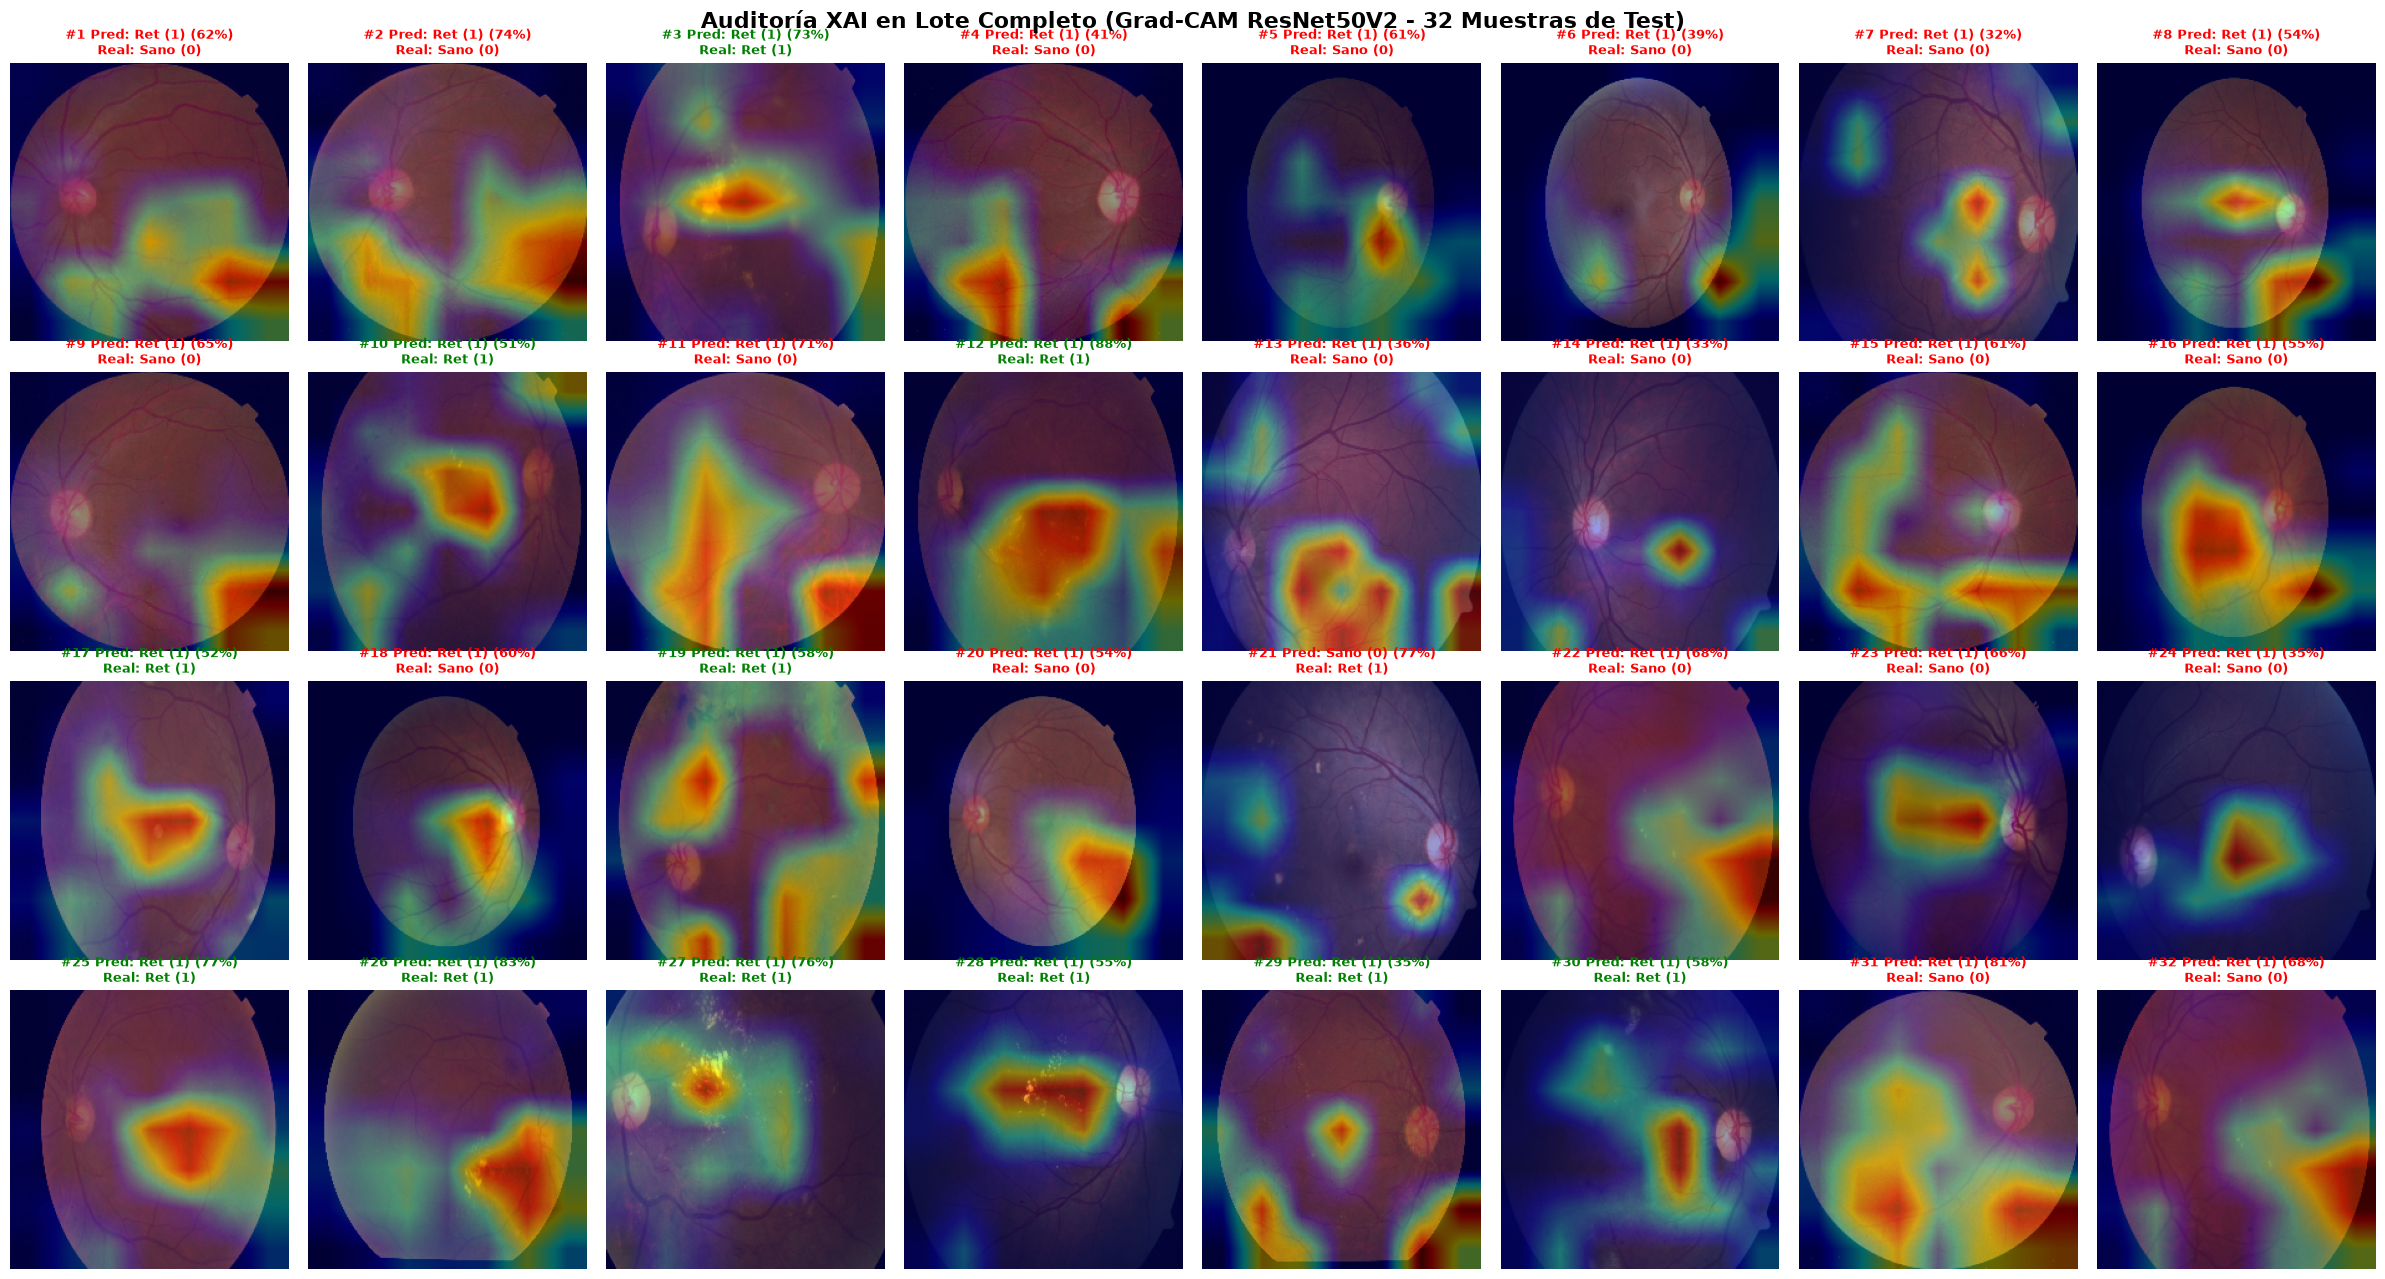

In [72]:
# =====================================================================
# 2. EXTRAER UN LOTE COMPLETO DEL TEST_DATASET Y EVALUAR GRAD-CAM
# =====================================================================
# Extracción de un lote de 32 imágenes
for lote_imagenes, lote_etiquetas in test_dataset.take(1):
    lote_img_np = lote_imagenes.numpy()
    lote_lbl_np = lote_etiquetas.numpy()
    break

# Cálculo de Grad-CAM vectorizado para las 32 muestras
heatmaps_lote, probs_lote = generar_gradcam_lote_resnet(model_resnet_xai, lote_img_np)

# =====================================================================
# 3. RENDERIZADO EN CUADRÍCULA DE 4x8 (32 RETINOGRAFÍAS SUPERPUESTAS)
# =====================================================================
fig, axes = plt.subplots(4, 8, figsize=(24, 13))
axes = axes.flatten()

UMBRAL = 0.3

for i in range(len(lote_img_np)):
    img_orig = lote_img_np[i].astype("uint8")
    label_real = lote_lbl_np[i]
    prob_predicha = probs_lote[i]

    # Post-procesamiento de color con OpenCV por imagen
    h, w, _ = img_orig.shape
    heatmap_resized = cv2.resize(heatmaps_lote[i], (w, h))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # Mezcla transparente (60% imagen original + 40% mapa de calor)
    superposicion = cv2.addWeighted(img_orig, 0.6, heatmap_color, 0.4, 0)

    # Interpretación clínica y estado de la predicción
    pred_clase = 1 if prob_predicha > UMBRAL else 0
    confianza = prob_predicha * 100 if pred_clase == 1 else (1 - prob_predicha) * 100
    es_correcto = (pred_clase == label_real)

    # Renderizado de la imagen superpuesta
    axes[i].imshow(superposicion)

    # Título dinámico con código de color
    color_titulo = "green" if es_correcto else "red"
    txt_pred = "Ret (1)" if pred_clase == 1 else "Sano (0)"
    txt_real = "Ret (1)" if label_real == 1 else "Sano (0)"

    axes[i].set_title(f"#{i+1} Pred: {txt_pred} ({confianza:.0f}%)\nReal: {txt_real}",
                      color=color_titulo, fontweight='bold', fontsize=9)
    axes[i].axis("off")

plt.suptitle("Auditoría XAI en Lote Completo (Grad-CAM ResNet50V2 - 32 Muestras de Test)",
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()